# **社群媒體分析 期末專案_第19組**
- 教授：黃三益
- 組員：M144020015 許鉦偉、M144020045 房冠葦、M144020058 黃鈞浩、M144020061 黃博章
- **YT影片連結**：https://www.youtube.com/watch?v=1rE_6kOFqLI
---

## 主題：各家銀行信用卡分析

### 動機分析與目的

信用卡是台灣民眾日常消費中最常使用的金融工具之一，各家銀行推出的信用卡產品在回饋機制、年費條件與申辦門檻上差異顯著。然而，官方行銷資訊往往著重於優點呈現，難以反映真實使用者的實際感受。

PTT 信用卡版（creditcard）是台灣最具代表性的信用卡討論社群，使用者在此分享核卡心得、詢問問題、交流優惠資訊，推噓機制也讓社群能對文章品質進行集體評價。本研究以此為資料來源，針對台新、永豐、玉山、國泰四家銀行進行社群媒體分析，目的如下：

1. **了解各銀行的討論焦點差異**：透過詞頻分析與主題模型，找出各銀行被使用者最常討論的面向（回饋、申辦、客服、權益等）。
2. **分析討論趨勢的時間變化**：觀察 2021 至 2026 年間各銀行討論聲量的消長，識別特定高峰月份是否對應現實事件。
3. **探索 PTT 信用卡社群的互動結構**：透過社群網路分析，找出核心意見領袖與各銀行的核心討論族群。

---

### 資料集說明
- 使用課堂上所教學的 Tarflow 來進行 PTT 爬蟲，爬蟲版面為 creditcard（信用卡）
- 時間：2021/5/1 ～ 2026/5/1
- 分別爬取四家銀行相關文章：永豐銀行、玉山銀行、國泰銀行、台新銀行
1. 永豐銀行 共 1,243 筆
2. 玉山銀行 共 1,122 筆
3. 國泰銀行 共 852 筆
4. 台新銀行 共 1,029 筆
- 總共 **4,246 筆**資料，合併為資料集 `creditcard_all_data`

---

### 大綱目錄

| 章節 | 內容 |
|------|------|
| **1. 載入套件** | 匯入分析所需套件 |
| **2. 資料前處理** | 欄位篩選、日期轉換、JIEBA 斷詞、PTT 推噓解析 |
| **3. 詞頻與文字雲** | 整體詞頻 Top 10、各銀行詞彙比較、文字雲視覺化 |
| **4. 情緒分析** | 以 artTag 與 ptt_score 雙指標評估情緒分布 |
| **5. LDA 主題模型** | 語料庫建立、最佳主題數評估、主題命名、跨銀行主題比較 |
| **6. 時間趨勢分析** | 月/年度討論量趨勢、高峰標記、LDA 主題熱度演變 |
| **7. 社群網路分析** | 用戶互動網路建立、中心度分析、pyvis 視覺化、各銀行核心用戶 |
| **8. 整體分析總結** | 跨章節發現彙整與研究限制說明 |

## 1. 載入套件

In [1]:
import sys
!{sys.executable} -m pip install jieba scikit-learn gensim wordcloud nltk pyLDAvis networkx pyvis


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# =========================
# 基本工具
# =========================
import os
import re
import gc
import time
import json
import warnings
import logging
from functools import reduce
from collections import Counter
from pprint import pprint

# 關掉警告洗版
warnings.filterwarnings("ignore")
logging.disable(logging.CRITICAL)

# =========================
# 資料處理
# =========================
import numpy as np
import pandas as pd

# =========================
# 視覺化
# =========================
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
from matplotlib.colors import Colormap
from wordcloud import WordCloud

# =========================
# 中文斷詞與文字處理
# =========================
import jieba
from nltk import ngrams, FreqDist
from sklearn.feature_extraction.text import (
    CountVectorizer,
    TfidfVectorizer,
    TfidfTransformer
)

# =========================
# Topic Modeling / Gensim
# =========================
from gensim.corpora import Dictionary
from gensim.models import LdaModel, CoherenceModel
from gensim.models.ldamulticore import LdaMulticore
from gensim.matutils import corpus2csc, corpus2dense, Sparse2Corpus

# =========================
# LDA 視覺化
# =========================
import pyLDAvis
import pyLDAvis.gensim_models

# =========================
# 網路分析
# =========================
import networkx as nx
from pyvis.network import Network

In [3]:
import logging
logging.basicConfig(format='%(asctime)s : %(levelname)s : %(message)s', level=logging.INFO)

In [4]:
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei']  # 微軟正黑體
plt.rcParams['axes.unicode_minus'] = False

FontPath = 'SourceHanSansTW-Regular.otf' # 設定字型

In [5]:
# colab專用，本地端請跳過此 cell
# import os
# import glob
# import matplotlib
# import matplotlib.pyplot as plt
# import matplotlib.font_manager as fm
#
# # 刪掉之前壞掉的字型檔
# bad_font = "SourceHanSansTW-Regular.otf"
# if os.path.exists(bad_font):
#     os.remove(bad_font)
#
# # 先找系統裡已經存在的中文字型
# font_candidates = []
#
# font_candidates += glob.glob("/usr/share/fonts/**/*NotoSansCJK*.ttc", recursive=True)
# font_candidates += glob.glob("/usr/share/fonts/**/*NotoSerifCJK*.ttc", recursive=True)
# font_candidates += glob.glob("/usr/share/fonts/**/*wqy*.ttc", recursive=True)
# font_candidates += glob.glob("/usr/share/fonts/**/*uming*.ttc", recursive=True)
# font_candidates += glob.glob("/usr/share/fonts/**/*NotoSansCJK*.otf", recursive=True)
# font_candidates += glob.glob("/usr/share/fonts/**/*NotoSerifCJK*.otf", recursive=True)
# font_candidates += glob.glob("/usr/share/fonts/**/*Noto*CJK*.otf", recursive=True)
#
# if len(font_candidates) == 0:
#     print("找不到中文字型，才開始安裝 fonts-noto-cjk...")
#     !apt-get install -y fonts-noto-cjk
#
#     # 清除 matplotlib 字型快取，讓新安裝的字型生效
#     cache_dir = matplotlib.get_cachedir()
#     for f in glob.glob(os.path.join(cache_dir, "fontlist*.json")):
#         os.remove(f)
#     fm.fontManager = fm.FontManager()
#
#     font_candidates += glob.glob("/usr/share/fonts/**/*NotoSansCJK*.ttc", recursive=True)
#     font_candidates += glob.glob("/usr/share/fonts/**/*NotoSerifCJK*.ttc", recursive=True)
#     font_candidates += glob.glob("/usr/share/fonts/**/*NotoSansCJK*.otf", recursive=True)
#     font_candidates += glob.glob("/usr/share/fonts/**/*NotoSerifCJK*.otf", recursive=True)
#     font_candidates += glob.glob("/usr/share/fonts/**/*Noto*CJK*.otf", recursive=True)
#     font_candidates += glob.glob("/usr/share/fonts/**/*Noto*CJK*.ttc", recursive=True)
#
# if len(font_candidates) == 0:
#     raise FileNotFoundError("仍然找不到中文字型")
#
# FontPath = font_candidates[0]
#
# print("使用字型檔：", FontPath)
#
# # 設定 matplotlib 中文字型
# fm.fontManager.addfont(FontPath)
# font_prop = fm.FontProperties(fname=FontPath)
# font_name = font_prop.get_name()
#
# plt.rcParams["font.family"] = "sans-serif"
# plt.rcParams["font.sans-serif"] = [font_name, "DejaVu Sans"]
# plt.rcParams["axes.unicode_minus"] = False
#
# print("Matplotlib 字型：", font_name)

## 2. 資料前處理

**資料來源**：PTT 信用卡版爬蟲資料  
**欄位說明**：
| 欄位 | 說明 |
|------|------|
| `bank` | 銀行別（台新、永豐、玉山、國泰…） |
| `artTitle` | 文章標題（含 [心得]/[問題]/[情報] 等標籤） |
| `artDate` | 發文時間 |
| `artPoster` | 發文者 ID |
| `artContent` | 文章內文 |
| `artComment` | PTT 推噓留言（JSON 格式） |

In [6]:
df = pd.read_csv('Final report\\creditcard_all_data.csv')

# 保留需要的欄位
df = df[['bank', 'system_id', 'artTitle', 'artDate',
         'artPoster', 'artCatagory', 'artContent', 'artComment']]

df['artDate_raw'] = df['artDate'].copy()

print(f'總資料量：{len(df):,} 筆')
df.head(3)

總資料量：4,246 筆


,bank,system_id,artTitle,artDate,artPoster,artCatagory,artContent,artComment,artDate_raw
0,台新,1,[建議]悠遊卡自動儲值的信用卡選擇,2021-05-04 23:51:31,partiiboy,creditcard,[職業類別] :資訊業\n\n[目前工作年資] :2年\n\n[年齡] :24\n\n[年收...,"[{""cmtStatus"": ""推"", ""cmtPoster"": ""annielaurie""...",2021-05-04 23:51:31
1,台新,2,[心得]花旗現金回饋plus鈦金卡核卡,2021-05-07 22:46:35,nice0708,creditcard,★職業類別：科技業\n\n★年資：4.5y\n\n★年齡：27y\n\n★申請卡片：花旗現金...,"[{""cmtStatus"": ""推"", ""cmtPoster"": ""tenghui"", ""c...",2021-05-07 22:46:35
2,台新,3,[心得]中信英雄聯盟卡核卡,2021-05-12 17:30:40,hedy0930,creditcard,★職業類別：待業 嗚嗚嗚\n\n★年資：0年\n\n★年齡：32\n\n★申請卡片：中信英...,"[{""cmtStatus"": ""推"", ""cmtPoster"": ""hy6jao"", ""cm...",2021-05-12 17:30:40


In [7]:
# 設定繁體中文詞庫
jieba.set_dictionary("dict.txt.big")

# 加入一些常見信用卡 / 銀行詞，避免被切太碎
custom_words = [
    # 銀行名稱
    "國泰世華", "中國信託", "上海商銀", "華南銀行",
    "第一銀行", "遠東商銀", "台北富邦",
    "玉山銀行", "台新銀行", "永豐銀行", "聯邦銀行",
    "星展銀行", "新光銀行", "兆豐銀行", "匯豐銀行",
    "凱基銀行", "彰化銀行", "樂天銀行", "渣打銀行",
    "元大銀行", "陽信銀行", "花旗銀行",

    # 信用卡常見詞
    "聯名卡", "貴賓室", "手續費", "白金卡", "首刷禮",
    "免年費", "現金回饋", "悠遊卡", "一卡通", "街口支付",
    "行動支付", "分期付款", "機場接送", "海外消費",
    "國內消費", "帳單折抵", "刷卡金", "財力證明"
]

for w in custom_words:
    jieba.add_word(w)


# =========================
# 讀取原本 stopwords
# =========================

with open("stop_words.txt", encoding="utf-8") as f:
    stopWords = set(line.strip() for line in f.readlines() if line.strip())


# =========================
# 手動停用字
# =========================

stopwords_manual = [
    # PTT / 口語常見無意義詞
    "請問", "有人", "大家", "小弟", "小妹", "如題", "想問", "請益",
    "感謝", "謝謝", "不好意思", "抱歉", "版友", "文章", "留言",
    "心得", "分享", "詢問", "推薦", "建議", "看看", "麻煩",

    # 一般語意太弱的詞
    "可以", "沒有", "覺得", "一直", "真的", "應該", "可能",
    "如果", "因為", "所以", "但是", "不過", "還是", "就是",
    "這個", "那個", "這張", "這次", "目前", "現在", "之前",
    "之後", "最近", "一樣", "比較", "自己", "直接",
    "看到", "知道", "需要", "使用", "感覺", "是不是",
    "有沒有", "一下", "這樣", "這邊", "那邊", "以上", "以下",
    "好像", "有點", "不到", "不用", "只能", "想要", "來說",

    # 信用卡版背景詞
    # 銀行名稱保留，但這三個太像資料背景，刪掉
    "銀行", "信用卡", "卡片",

    # 時間詞
    "時間", "今年", "去年", "明年", "期間", "每月", "月底",
    "年度", "下午", "最後", "一次", "一年", "每個",
    "今天", "當月", "當天", "晚上", "早上", "當時", "剛剛",
    "一個月", "幾天", "小時", "半年", "年底", "日期",

    # 流程／描述型泛用詞
    "提供", "收到", "通知", "更新", "新增", "發現", "希望",
    "主要", "問題", "原本", "第一", "方式", "部分", "資料",
    "資訊", "內容", "相關", "說明", "表示", "確認", "完成",
    "符合", "選擇", "適用", "透過", "拿到", "顯示",
    "注意", "處理", "告知", "參考", "完整", "特別",
    "至少", "一點", "一些", "一筆", "一張", "兩張", "三個",
    "兩個", "所有", "包含", "進行", "即可", "順便",
    "算是", "左右", "完全", "一定", "繼續", "變成",

    # 從高頻詞表看到仍偏雜訊的詞
    "最高", "超過", "成功", "是否", "已經", "自動",
    "最佳", "業務", "台灣", "台北", "電話", "工作",
    "官網", "計算", "查詢", "無法", "不錯", "公司",
    "連結", "手機", "功能", "取消", "客戶", "系統",
    "考慮", "機會", "推出", "網頁", "網站", "確定",
    "主力", "方便", "獲得", "參加", "限制", "辦法",
    "預計", "狀況", "單位", "額外", "開放", "要求",
    "排除", "朋友", "整理", "新聞", "平常", "記得",
    "第一次", "情況", "手上", "行動", "實體", "電子",
    "類別", "過程", "持有", "調整", "指定", "累積",
    "金額", "萬元", "每期", "服務", "生活", "金融",
    "平台", "理財", "本行", "實際", "附上", "簡單",
    "以前", "網址", "還要", "關係", "原因", "東西",
    "全部", "沒想到", "順利", "遇到", "上面", "過去",
    "習慣", "影響", "研究", "地方", "家人", "適合",
    "商品", "經驗", "意外", "福利", "民眾", "享有",
    "拿來", "記錄", "有效",

    # 百分比詞
    "1%", "2%", "3%", "4%", "5%", "6%", "7%", "8%", "9%",
    "10%", "100%",

    # 網路雜訊
    "http", "https", "www", "com", "app", "APP", "推", "噓", "→", "←"
]

stopWords = stopWords | set(stopwords_manual)


# =========================
# 重要分析詞：避免被原本 stop_words.txt 誤刪
# =========================

keep_words = {
    # 核心信用卡議題
    "回饋", "消費", "上限", "申請", "額度", "刷卡", "活動",
    "申辦", "核卡", "聯名卡", "現金", "支付", "登錄",
    "客服", "帳單", "匯率", "加碼", "綁定", "悠遊",
    "帳戶", "簡訊", "財力", "證明", "通路",

    # 申辦 / 核卡相關
    "調額", "線上", "海外", "權益", "職業", "年收入",
    "年資", "年齡", "點數", "網購", "國外", "日本",
    "分期", "街口", "國內", "長榮", "機場", "交易",
    "扣繳", "年費", "換匯", "照會",
    "加辦", "機票", "旅遊", "航空", "繳稅", "貴賓室",
    "新戶", "錢包", "出國", "折抵", "手續費", "加值",
    "購物", "接送", "門檻", "資格", "簽帳", "餐廳",
    "繳費", "飯店", "會員", "利率", "停車", "兌換",
    "免費", "方案", "哩程", "里程", "台幣", "外幣", "貸款",
    "辦卡", "紅利", "卡面", "超商", "聯徵", "加油",
    "付款", "入帳", "持卡人", "保費", "薪資",
    "高鐵", "任務", "條件", "公告", "需求", "婉拒",
    "紀錄", "結帳", "百貨", "補件", "滿額", "失敗",
    "開戶", "審核", "扣款", "儲值", "雙幣", "存款",
    "次數", "商店", "送件",

    # 信用卡等級 / 產品名稱
    "世界", "卓越", "無限", "御璽", "商務", "頂級",
    "金卡", "白金卡", "大戶", "玫瑰", "幣倍", "英雄",
    "極致", "太陽", "熊本", "旅人"
}

# 把重要詞從停用字中救回來
stopWords = stopWords - keep_words


# =========================
# 銀行名稱統一
# 保留銀行名稱，但把被切碎的銀行名統一
# =========================

bank_alias_map = {
    # 國泰世華
    "國泰世華": "國泰",
    "世華": "國泰",

    # 中國信託
    "中國信託": "中信",
    "中國": "中信",
    "信託": "中信",

    # 上海商銀
    "上海商銀": "上海商銀",
    "上海": "上海商銀",
    "商銀": "上海商銀",

    # 華南銀行
    "華南銀行": "華南",

    # 第一銀行
    "第一銀行": "一銀",

    # 遠東商銀
    "遠東商銀": "遠東",

    # 其他常見完整名稱
    "台北富邦": "富邦",
    "玉山銀行": "玉山",
    "台新銀行": "台新",
    "永豐銀行": "永豐",
    "聯邦銀行": "聯邦",
    "星展銀行": "星展",
    "新光銀行": "新光",
    "兆豐銀行": "兆豐",
    "匯豐銀行": "匯豐",
    "凱基銀行": "凱基",
    "彰化銀行": "彰銀",
    "彰銀銀行": "彰銀",
    "樂天銀行": "樂天",
    "渣打銀行": "渣打",
    "元大銀行": "元大",
    "陽信銀行": "陽信",
    "花旗銀行": "花旗"
}


def normalize_bank_tokens(words):
    normalized = []

    for w in words:
        new_w = bank_alias_map.get(w, w)

        # 避免「中國」「信託」都變成「中信」後連續重複
        # 例如：["中國", "信託"] -> ["中信"]
        if len(normalized) == 0 or normalized[-1] != new_w:
            normalized.append(new_w)

    return normalized


# =========================
# 清洗與斷詞
# =========================

def clean_text(row):
    if not isinstance(row, str):
        return ""

    # 移除網址
    row = re.sub(r'https?://\S+', ' ', row)

    # 只保留中文、數字、百分比
    row = re.sub(r'[^\u4e00-\u9fff\u3400-\u4dbf0-9%]', ' ', row)

    return row


def getToken(row):
    row = clean_text(row)

    seg_list = jieba.cut(row, cut_all=False)

    seg_list = [
        w.strip()
        for w in seg_list
        if w.strip()
        and len(w.strip()) > 1
        and not re.fullmatch(r'\d+', w.strip())
        and not re.fullmatch(r'\d+%', w.strip())
    ]

    # 銀行名稱統一
    seg_list = normalize_bank_tokens(seg_list)

    # 停用字過濾
    seg_list = [
        w for w in seg_list
        if w not in stopWords
    ]

    return seg_list


# 產生斷詞欄位
df["words"] = df["artContent"].apply(getToken)

df.head()

,bank,system_id,artTitle,artDate,artPoster,artCatagory,artContent,artComment,artDate_raw,words
0,台新,1,[建議]悠遊卡自動儲值的信用卡選擇,2021-05-04 23:51:31,partiiboy,creditcard,[職業類別] :資訊業\n\n[目前工作年資] :2年\n\n[年齡] :24\n\n[年收...,"[{""cmtStatus"": ""推"", ""cmtPoster"": ""annielaurie""...",2021-05-04 23:51:31,"[職業, 資訊業, 年資, 年齡, 年收入, 貸款, 財力證明, 轉帳, 額度, 台新, 兆..."
1,台新,2,[心得]花旗現金回饋plus鈦金卡核卡,2021-05-07 22:46:35,nice0708,creditcard,★職業類別：科技業\n\n★年資：4.5y\n\n★年齡：27y\n\n★申請卡片：花旗現金...,"[{""cmtStatus"": ""推"", ""cmtPoster"": ""tenghui"", ""c...",2021-05-07 22:46:35,"[職業, 科技, 年資, 年齡, 申請, 花旗, 現金回饋, 金卡, 年收入, 財力證明, ..."
2,台新,3,[心得]中信英雄聯盟卡核卡,2021-05-12 17:30:40,hedy0930,creditcard,★職業類別：待業 嗚嗚嗚\n\n★年資：0年\n\n★年齡：32\n\n★申請卡片：中信英...,"[{""cmtStatus"": ""推"", ""cmtPoster"": ""hy6jao"", ""cm...",2021-05-12 17:30:40,"[職業, 待業, 嗚嗚, 年資, 年齡, 申請, 中信, 英雄, 聯盟, 年收入, 財力證明..."
3,台新,4,[心得]美國運通信用白金卡核卡,2021-05-15 07:19:57,tank159,creditcard,★職業類別：保全\n\n★年資：五個月\n\n★年齡：31\n\n★申請卡片：美國運通信用白...,"[{""cmtStatus"": ""推"", ""cmtPoster"": ""xerophil"", ""...",2021-05-15 07:19:57,"[職業, 保全, 年資, 五個, 年齡, 申請, 美國, 運通, 信用, 白金卡, 年收入,..."
4,台新,5,[心得]學生台新Flygo核卡,2021-05-19 13:46:53,ray62020,creditcard,★職業類別：填家教業 （實際等8月出國唸碩）\n\n★年資：填1年\n\n★年齡：22\n\...,"[{""cmtStatus"": ""推"", ""cmtPoster"": ""obedu"", ""cmt...",2021-05-19 13:46:53,"[職業, 家教, 出國, 年資, 年齡, 申請, 台新, 年收入, 財力證明, 元大, 活存..."


## 3. 詞頻與文字雲

分兩個層次進行詞頻視覺化：
1. **整體詞頻** — 全部文章合併分析
2. **依銀行別** — 比較各銀行的討論焦點差異

### 3.1 整體詞頻 — 橫條圖 Top 10

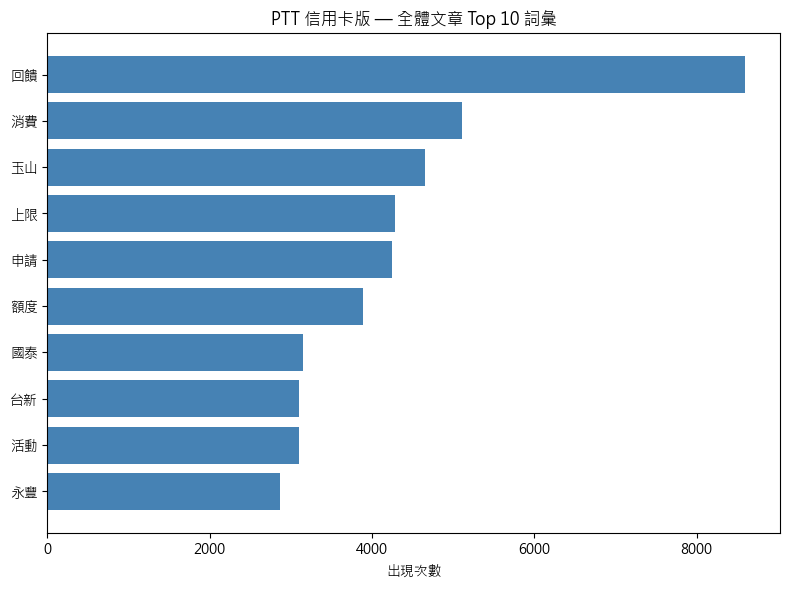

In [8]:
# 將所有文章的斷詞結果展平成單一 list
all_words = [word for words in df['words'] for word in words]
freq_dict = Counter(all_words)

# 轉成 DataFrame 方便畫圖
freq_df = (
    pd.DataFrame(freq_dict.items(), columns=['word', 'count'])
    .sort_values('count', ascending=False)
    .reset_index(drop=True)
)

# 繪製 Top 10 橫條圖
fig, ax = plt.subplots(figsize=(8, 6))
top10 = freq_df.head(10)
ax.barh(top10['word'], top10['count'], color='steelblue')
ax.invert_yaxis()
ax.set_xlabel('出現次數')
ax.set_title('PTT 信用卡版 — 全體文章 Top 10 詞彙')
plt.tight_layout()
plt.show()


### 3.2 整體文字雲

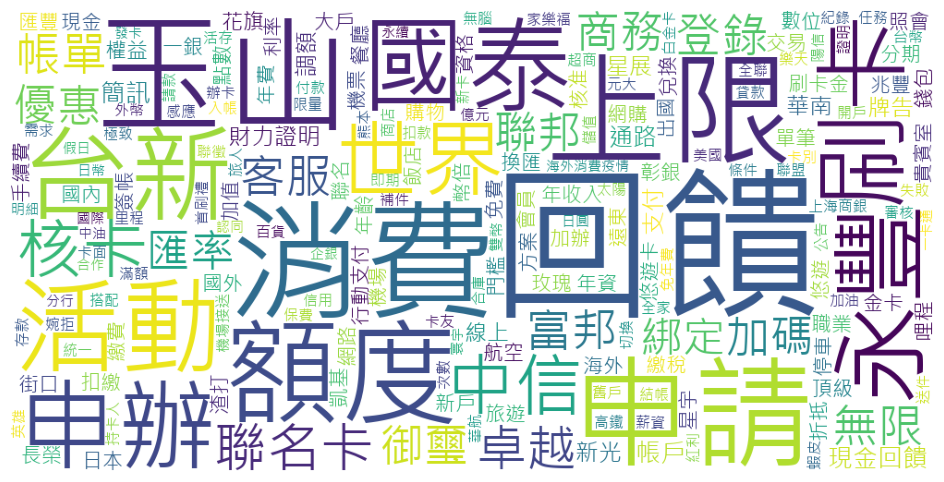

In [9]:
# 使用 Windows 內建中文字型（微軟正黑體）
FontPath = r"C:\Windows\Fonts\msjh.ttc"

# 定義建立 WordCloud 的輔助函式
def make_wc(**kwargs):
    return WordCloud(
        font_path=FontPath,
        background_color='white',
        **kwargs
    )

wc = make_wc(width=1000, height=500)
wc.generate_from_frequencies(freq_dict)

plt.figure(figsize=(12, 6))
plt.imshow(wc)
plt.axis("off")
plt.show()

### 3.3 依銀行別 — 各銀行 Top 10 詞彙橫條圖

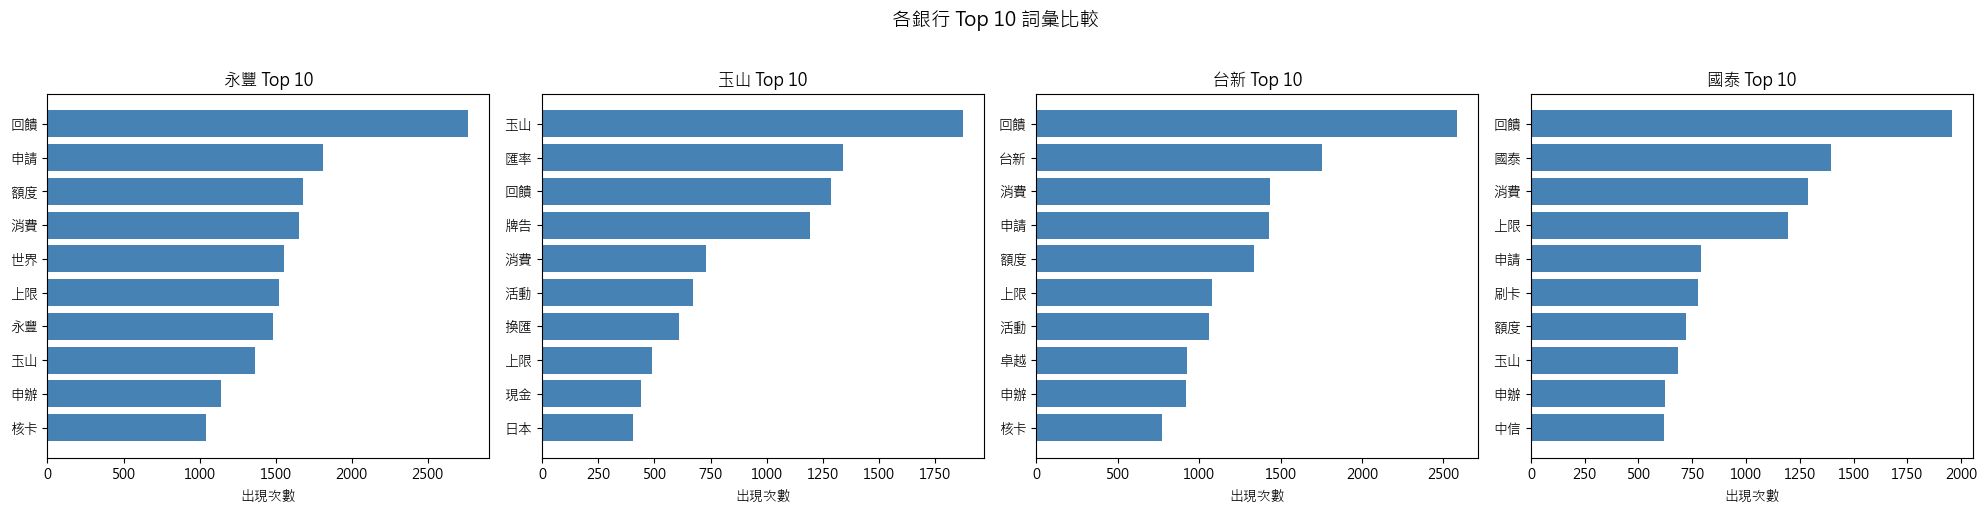

In [10]:
banks = df['bank'].value_counts().index.tolist()  # 依討論量排序
n = len(banks)

fig, axes = plt.subplots(1, n, figsize=(5 * n, 5), sharey=False)
if n == 1:
    axes = [axes]

for ax, bank in zip(axes, banks):
    # 取出該銀行所有斷詞結果
    bank_words = [
        word
        for words in df.loc[df['bank'] == bank, 'words']
        for word in words
    ]
    bank_freq = Counter(bank_words).most_common(10)
    words_list, counts = zip(*bank_freq) if bank_freq else ([], [])

    ax.barh(list(words_list), list(counts), color='steelblue')
    ax.invert_yaxis()
    ax.set_title(f'{bank} Top 10')
    ax.set_xlabel('出現次數')

plt.suptitle('各銀行 Top 10 詞彙比較', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

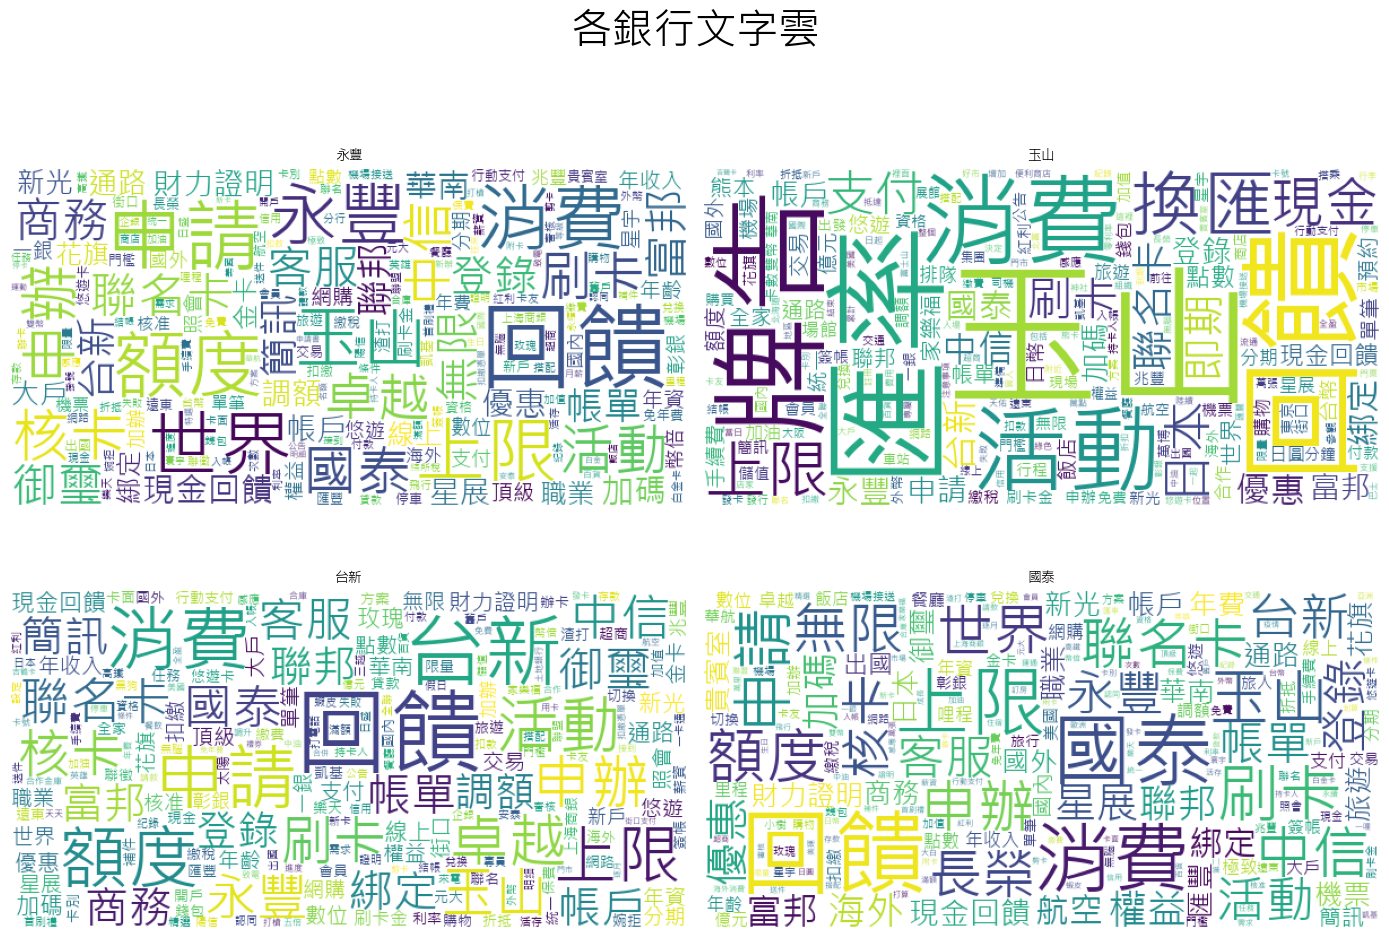

In [11]:
from matplotlib.font_manager import FontProperties
_fp = FontProperties(fname=FontPath)

# 計算每家銀行的詞頻 dict（統一在這裡算好，後面步驟也會用到）
bank_freq_dict = {}
for bank in banks:
    words = [
        word
        for words in df.loc[df['bank'] == bank, 'words']
        for word in words
    ]
    bank_freq_dict[bank] = Counter(words)

# 畫 2×2（或依銀行數量自動調整）文字雲
cols = 2
rows = (n + 1) // 2
fig, axes = plt.subplots(rows, cols, figsize=(14, 5 * rows))
axes = axes.flatten()

for i, bank in enumerate(banks):
    wc = make_wc(width=600, height=300)
    if bank_freq_dict[bank]:
        wc.generate_from_frequencies(bank_freq_dict[bank])
        axes[i].imshow(wc)
    axes[i].axis('off')
    axes[i].set_title(f'{bank}', fontsize=20, fontproperties=_fp)

# 隱藏多餘的子圖
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('各銀行文字雲', fontsize=30, y=1.01, fontproperties=_fp)
plt.tight_layout()
plt.show()

### 詞頻分析小結

1. **整體詞頻**：PTT 信用卡版的討論詞彙高度集中於「回饋」、「消費」、「申請」、「額度」、「刷卡」等核心字，**反映使用者最關注的三大面向為——回饋機制、申辦流程與消費限額。**

2. **各銀行差異**：
- 各銀行文字雲呈現出明顯的品牌特性，例如玉山的高頻詞偏向「匯率」「聯名卡」，反映玉山外幣換匯產品的獨特性；永豐的詞彙分布較為均勻，顯示討論面向較廣泛。
- 「回饋」一詞在所有銀行中均為最高頻詞彙，顯示回饋率是使用者選擇信用卡的最核心考量。

3. **分析限制**：詞頻分析僅能呈現「哪些詞出現最多」，無法判斷詞彙的語境（正面或負面使用）。後續 LDA 主題模型將進一步探討詞彙的共現脈絡。

## 4. 情緒分析

- 因為本資料沒有星級與具體評分，改用兩種替代指標：

| 指標 | 說明 |
|------|------|
| **artTag 情緒** | `[心得]`→正向、`[問題]`→負向、其他→中立 |
| **PTT 推噓分數** | `ptt_score = push - boo`，越高表示社群反應越正面 |

兩個指標互補：artTag 反映「發文者意圖」，ptt_score 反映「社群整體反應」

### 4.1 建立情緒欄位與分布

In [12]:
# ── 從標題抽取 artTag ─────────────────
def parse_art_date(x):
    if pd.isna(x):
        return pd.NaT

    s = str(x).strip()

    if s in ['', 'nan', 'NaT', 'None']:
        return pd.NaT

    # 統一日期分隔符號
    s = s.replace('/', '-')

    return pd.to_datetime(s, errors='coerce')

df['artDate'] = df['artDate_raw'].apply(parse_art_date)
df['yearMonth'] = df['artDate'].dt.to_period('M')

# 刪除日期無法解析的異常資料

bad_date = df[df['yearMonth'].isna()].copy()

# 刪除 yearMonth 是空值的資料
df = df.dropna(subset=['yearMonth']).copy()
df = df.reset_index(drop=True)
df['artTag'] = df['artTitle'].str.extract(r'\[([^\]]+)\]')[0]

# ──  解析 PTT 推噓 → ptt_score ─────────
def parse_ptt_score(cmt_str):
    if pd.isna(cmt_str):
        return 0, 0, 0
    try:
        cmts = json.loads(cmt_str)
        push = sum(1 for c in cmts if c.get('cmtStatus') == '推')
        boo  = sum(1 for c in cmts if c.get('cmtStatus') == '噓')
        neu  = sum(1 for c in cmts if c.get('cmtStatus') == '→')
        return push, boo, neu
    except Exception:
        return 0, 0, 0

df[['push', 'boo', 'neutral_cmt']] = df['artComment'].apply(
    lambda x: pd.Series(parse_ptt_score(x))
)
df['ptt_score'] = df['push'] - df['boo']

# ── 情緒分析───────────────
tag_map = {
    '心得': 'positive', '問題': 'negative', '情報': 'neutral',
    '閒聊': 'neutral',  '建議': 'neutral',  '新聞': 'neutral',
    '討論': 'neutral',  '資訊': 'neutral',
}
df['sentiment'] = df['artTag'].map(tag_map).fillna('neutral')

print('=== 情緒分布（artTag 基礎）===')
print(df['sentiment'].value_counts())
print()
print('=== PTT 推噓分數描述統計 ===')
print(df['ptt_score'].describe().round(2))

=== 情緒分布（artTag 基礎）===
sentiment
neutral     2119
positive    1167
negative     935
Name: count, dtype: int64

=== PTT 推噓分數描述統計 ===
count    4221.00
mean       19.85
std        43.80
min      -193.00
25%         4.00
50%        11.00
75%        24.00
max       929.00
Name: ptt_score, dtype: float64


### 4.2 整體的情緒分布

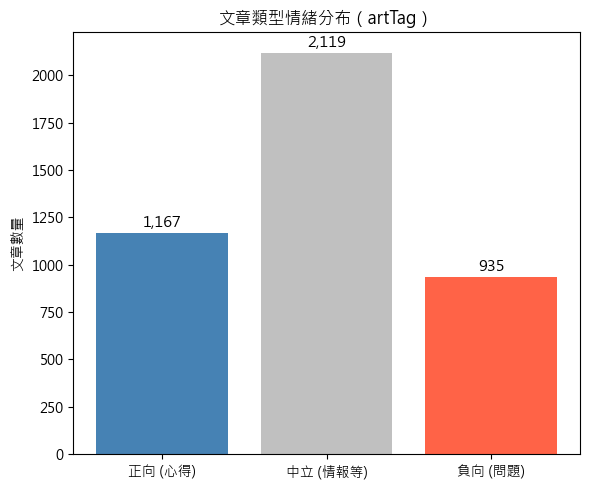

In [13]:
fig, ax = plt.subplots(figsize=(6, 5))

sent_counts = df['sentiment'].value_counts().reindex(['positive', 'neutral', 'negative'])
bars = ax.bar(
    ['正向 (心得)', '中立 (情報等)', '負向 (問題)'],
    sent_counts.values,
    color=['steelblue', 'silver', 'tomato'],
    edgecolor='none'
)

for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 10,
        f'{int(bar.get_height()):,}',
        ha='center', va='bottom', fontsize=11
    )

ax.set_title('文章類型情緒分布（artTag）')
ax.set_ylabel('文章數量')

plt.tight_layout()
plt.show()

### 4.3 各家銀行的情緒分布

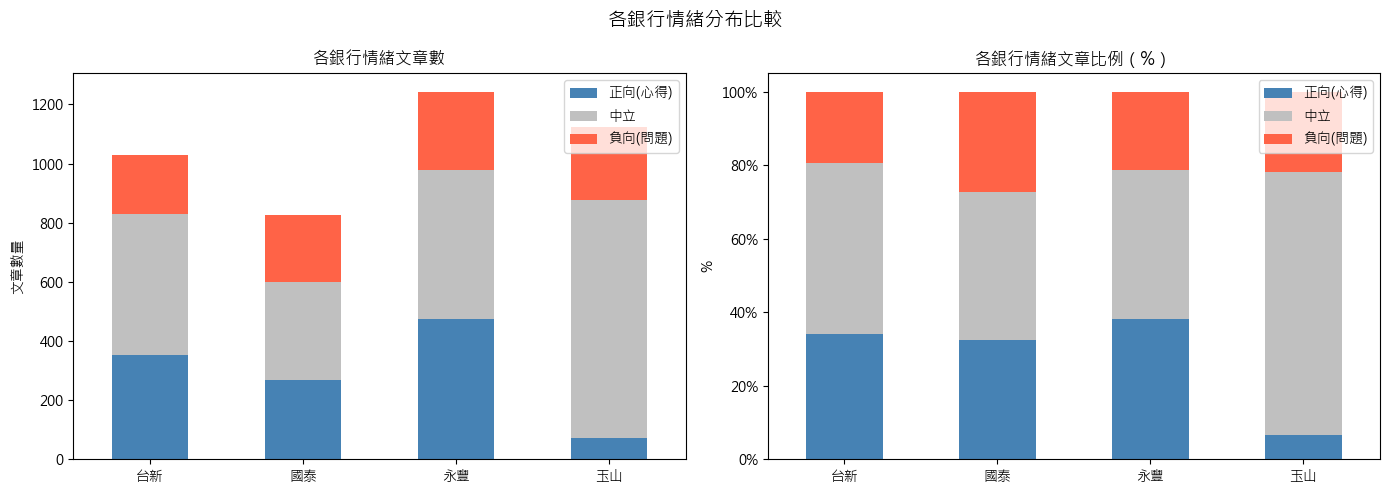


各銀行情緒比例：
sentiment  positive  neutral  negative
bank                                  
台新             34.2     46.4      19.4
國泰             32.4     40.3      27.3
永豐             38.1     40.5      21.3
玉山              6.5     71.7      21.7


In [14]:
# 1. 解決圖表中文顯示問題 (請依據你使用的字體調整)
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei'] # 如果是用思源黑體就改成 'Noto Sans TC'
plt.rcParams['axes.unicode_minus'] = False

# 2. 資料整理：各銀行各情緒的數量
bank_sent = (
    df.groupby(['bank', 'sentiment'])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=['positive', 'neutral', 'negative'], fill_value=0)
)

# 3. 轉成比例（百分比）
bank_sent_pct = bank_sent.div(bank_sent.sum(axis=1), axis=0) * 100

# 4. 開始畫圖
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左圖：絕對數量
bank_sent.plot(
    kind='bar', ax=axes[0], stacked=True,
    color=['steelblue', 'silver', 'tomato'],
    edgecolor='none'
)
axes[0].set_title('各銀行情緒文章數')
axes[0].set_ylabel('文章數量')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=0) # 讓銀行名稱橫向顯示，比較好閱讀
axes[0].legend(['正向(心得)', '中立', '負向(問題)'], loc='upper right')

# 右圖：比例
bank_sent_pct.plot(
    kind='bar', ax=axes[1], stacked=True,
    color=['steelblue', 'silver', 'tomato'],
    edgecolor='none'
)
axes[1].set_title('各銀行情緒文章比例（%）')
axes[1].set_ylabel('%')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=0)
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter())
axes[1].legend(['正向(心得)', '中立', '負向(問題)'], loc='upper right')

plt.suptitle('各銀行情緒分布比較', fontsize=14)
plt.tight_layout()
plt.show()

print('\n各銀行情緒比例：')
print(bank_sent_pct.round(1))

### 情緒分析小結

1. **整體分布**：以文章標籤（artTag）作為情緒代理，資料集中中立類文章（情報、閒聊等）佔比最高，其次為正向（心得），負向（問題）佔比最低，整體顯示 PTT 信用卡版以資訊交流為主，正向分享多於問題抱怨。

2. **各銀行差異**：各銀行的正向與負向文章比例差異不大，表示四家銀行在 PTT 上整體形象相近。若某銀行的負向（問題）比例明顯偏高，可能反映該銀行在特定服務面向上有較多使用者困擾。

3. **分析限制**：本節以 artTag 作為情緒分類的替代指標，存在一定程度的誤差（如 `[心得]` 文章內容不一定為正向）。若要提升準確性，建議後續搭配情感詞典或預訓練 NLP 模型進行更精確的情緒判斷。

### 5. LDA 主題模型

### 5.1 建立語料庫(Dictionary + corpus)

In [15]:
# 取出斷詞結果（df['words'] 來自前處理步驟）
docs = df['words'].tolist()

# 建立詞典
dictionary = Dictionary(docs)

# 過濾低頻與高頻詞
# no_below=5  → 出現在少於 5 篇文章的詞移除
# no_above=0.95 → 出現在超過 95% 文章的詞移除
dictionary.filter_extremes(no_below=5, no_above=0.95)

# 轉為 BoW 格式
corpus = [dictionary.doc2bow(doc) for doc in docs]

print(f'詞典大小：{len(dictionary):,} 個詞彙')
print(f'語料筆數：{len(corpus):,} 篇文章')
print(f'有效文件：{sum(1 for c in corpus if len(c) > 0):,} 篇')

詞典大小：6,368 個詞彙
語料筆數：4,221 篇文章
有效文件：4,216 篇


### 5.2 透過指標找出最佳主題數
- **Perplexity**：越小越好（模型對語料的困惑度）
- **PMI**：越大越好（主題內詞彙共現程度）

In [16]:
result_path = "lda_topic_eval_result.csv"

# 如果之前已經跑過部分結果，就讀回來
if os.path.exists(result_path):
    result_df = pd.read_csv(result_path)
    done_topics = set(result_df["topic_num"].astype(int))
    print("已完成 topic 數：", sorted(done_topics))
else:
    result_df = pd.DataFrame(columns=["topic_num", "perplexity", "pmi"])
    done_topics = set()

topic_num_list = range(2, 9)

for n in topic_num_list:
    if n in done_topics:
        print(f"topics={n} 已經跑過，跳過")
        continue

    print(f"\n開始 topics={n} ...")
    t1 = time.time()

    model = LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=n,
        random_state=42,
        passes=5,
        iterations=50
    )

    print("  LDA 訓練完成，開始算 perplexity...")

    loss = model.log_perplexity(corpus)
    perplexity = np.exp(-1. * loss)

    print("  perplexity 完成，開始算完整 PMI...")

    cm = CoherenceModel(
        model=model,
        texts=docs,
        dictionary=dictionary,
        coherence="c_npmi",
        topn=10,
        processes=1
    )

    pmi = cm.get_coherence()

    new_row = pd.DataFrame([{
        "topic_num": n,
        "perplexity": perplexity,
        "pmi": pmi
    }])

    result_df = pd.concat([result_df, new_row], ignore_index=True)
    result_df = result_df.sort_values("topic_num").reset_index(drop=True)


    result_df.to_csv(result_path, index=False, encoding="utf-8-sig")

    print(f"topics={n}  perplexity={perplexity:.1f}  pmi={pmi:.4f}  花費={time.time() - t1:.1f} 秒")
    print(f"已儲存到 {result_path}")

    del model
    del cm
    gc.collect()

result_df

已完成 topic 數： [2, 3, 4, 5, 6, 7, 8]
topics=2 已經跑過，跳過
topics=3 已經跑過，跳過
topics=4 已經跑過，跳過
topics=5 已經跑過，跳過
topics=6 已經跑過，跳過
topics=7 已經跑過，跳過
topics=8 已經跑過，跳過


,topic_num,perplexity,pmi
0,2,1405.360077,0.033540
1,3,1231.854485,0.041542
2,4,1135.978810,0.051954
3,5,1106.364706,0.057994
4,6,1113.997237,0.057710
5,7,1095.993022,0.061504
6,8,1105.028190,0.058985


   topic_num   perplexity       pmi
0          2  1405.360077  0.033540
1          3  1231.854485  0.041542
2          4  1135.978810  0.051954
3          5  1106.364706  0.057994
4          6  1113.997237  0.057710
5          7  1095.993022  0.061504
6          8  1105.028190  0.058985
topic_num       int32
perplexity    float64
pmi           float64
dtype: object


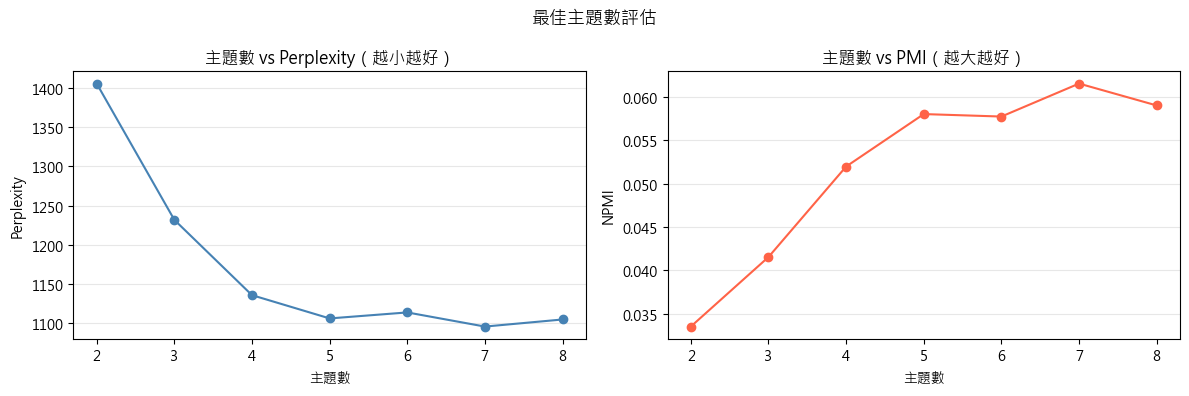

PMI 最高的主題數：7


In [17]:
# 避免前一次錯誤圖殘留
plt.close('all')

# 確保 result_df 欄位是數值型態，不然 matplotlib 可能會報 rint 錯
result_df = result_df.copy()

result_df['topic_num'] = pd.to_numeric(result_df['topic_num'], errors='coerce')
result_df['perplexity'] = pd.to_numeric(result_df['perplexity'], errors='coerce')
result_df['pmi'] = pd.to_numeric(result_df['pmi'], errors='coerce')

# 移除無法轉換的資料
result_df = result_df.dropna(subset=['topic_num', 'perplexity', 'pmi']).copy()

# 型態整理
result_df['topic_num'] = result_df['topic_num'].astype(int)
result_df['perplexity'] = result_df['perplexity'].astype(float)
result_df['pmi'] = result_df['pmi'].astype(float)

# 依主題數排序
result_df = result_df.sort_values('topic_num').reset_index(drop=True)

print(result_df)
print(result_df.dtypes)

# 繪圖
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(
    result_df['topic_num'].to_numpy(),
    result_df['perplexity'].to_numpy(),
    marker='o',
    color='steelblue'
)
axes[0].set_title('主題數 vs Perplexity（越小越好）')
axes[0].set_xlabel('主題數')
axes[0].set_ylabel('Perplexity')
axes[0].set_xticks(result_df['topic_num'].to_numpy())
axes[0].grid(axis='y', alpha=0.3)

axes[1].plot(
    result_df['topic_num'].to_numpy(),
    result_df['pmi'].to_numpy(),
    marker='o',
    color='tomato'
)
axes[1].set_title('主題數 vs PMI（越大越好）')
axes[1].set_xlabel('主題數')
axes[1].set_ylabel('NPMI')
axes[1].set_xticks(result_df['topic_num'].to_numpy())
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('最佳主題數評估', fontsize=13)
plt.tight_layout()
plt.show()

# 找 PMI 最高的主題數
best_n = int(result_df.loc[result_df['pmi'].idxmax(), 'topic_num'])
print(f'PMI 最高的主題數：{best_n}')

### 5.3 訓練最終 LDA 模型
- 採用 `num_topics=7`，`passes=10` 提高收斂品質

In [18]:
best_model = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=7,       # 依指標掃描結果調整
    random_state=42,
    passes=10           # 訓練次數提高，讓模型更收斂
)

print('=== 各主題 Top 10 代表字 ===')
for i, topic in best_model.print_topics(num_words=10):
    print(f'\nTopic {i+1}：')
    print(topic)

=== 各主題 Top 10 代表字 ===

Topic 1：
0.027*"億元" + 0.021*"刷卡" + 0.019*"國泰" + 0.018*"簽帳" + 0.013*"旅遊" + 0.013*"玉山" + 0.013*"中信" + 0.012*"萬張" + 0.011*"消費" + 0.010*"聯名卡"

Topic 2：
0.024*"長榮" + 0.020*"世界" + 0.020*"國泰" + 0.018*"無限" + 0.017*"卓越" + 0.016*"消費" + 0.014*"貴賓室" + 0.013*"機票" + 0.013*"航空" + 0.012*"商務"

Topic 3：
0.044*"申請" + 0.039*"額度" + 0.028*"申辦" + 0.026*"核卡" + 0.018*"國泰" + 0.014*"玉山" + 0.014*"中信" + 0.014*"財力證明" + 0.012*"台新" + 0.011*"永豐"

Topic 4：
0.060*"上限" + 0.046*"回饋" + 0.032*"消費" + 0.030*"聯名卡" + 0.028*"刷卡" + 0.023*"登錄" + 0.017*"永豐" + 0.017*"帳單" + 0.015*"悠遊" + 0.014*"聯邦"

Topic 5：
0.038*"回饋" + 0.036*"活動" + 0.032*"消費" + 0.024*"客服" + 0.017*"登錄" + 0.013*"加碼" + 0.009*"綁定" + 0.009*"交易" + 0.008*"刷卡" + 0.007*"國泰"

Topic 6：
0.017*"玉山" + 0.013*"消費" + 0.012*"活動" + 0.012*"聯名卡" + 0.011*"國泰" + 0.011*"家樂福" + 0.010*"回饋" + 0.009*"支付" + 0.009*"點數" + 0.008*"優惠"

Topic 7：
0.069*"回饋" + 0.033*"玉山" + 0.030*"匯率" + 0.023*"牌告" + 0.023*"永豐" + 0.021*"上限" + 0.018*"消費" + 0.014*"現金" + 0.013*"換匯" + 0.013*"大戶"


- 主題命名
- 根據上方各主題的代表字，為每個主題命名

In [19]:
topic_names = {
    0: '主題一：刷卡簽帳規模與銀行聯名卡',
    1: '主題二：航空聯名卡與高端旅遊權益',
    2: '主題三：申辦核卡與信用額度審核',
    3: '主題四：回饋上限、登錄與聯名卡優惠',
    4: '主題五：消費回饋活動與客服交易',
    5: '主題六：通路聯名卡與點數支付優惠',
    6: '主題七：外幣匯率、換匯與現金回饋'
}

print('主題命名完成：')
for k, v in topic_names.items():
    print(f'  Topic {k+1}: {v}')

主題命名完成：
  Topic 1: 主題一：刷卡簽帳規模與銀行聯名卡
  Topic 2: 主題二：航空聯名卡與高端旅遊權益
  Topic 3: 主題三：申辦核卡與信用額度審核
  Topic 4: 主題四：回饋上限、登錄與聯名卡優惠
  Topic 5: 主題五：消費回饋活動與客服交易
  Topic 6: 主題六：通路聯名卡與點數支付優惠
  Topic 7: 主題七：外幣匯率、換匯與現金回饋


### 5.4 pyLDAvis 互動視覺化

In [20]:
pyLDAvis.enable_notebook()
vis = pyLDAvis.gensim_models.prepare(best_model, corpus, dictionary)
vis

#pyLDAvis.save_html(vis, 'lda_creditcard.html')
#print('已儲存 lda_creditcard.html')

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
2      0.198964 -0.190067       1        1  26.734670
3      0.141306  0.215834       2        1  16.348415
1      0.017035 -0.189482       3        1  14.907769
6      0.077229  0.104538       4        1  14.035371
4     -0.033452  0.087520       5        1  13.500907
5     -0.235879 -0.010163       6        1   7.835334
0     -0.165203 -0.018178       7        1   6.637534, topic_info=     Term         Freq        Total Category  logprob  loglift
533    上限  4482.000000  4482.000000  Default  30.0000  30.0000
7      回饋  8300.000000  8300.000000  Default  29.0000  29.0000
22     申請  4125.000000  4125.000000  Default  28.0000  28.0000
36     額度  3633.000000  3633.000000  Default  27.0000  27.0000
48     核卡  2312.000000  2312.000000  Default  26.0000  26.0000
...   ...          ...          ...      ...      ...      ...
6      台新   156.699057  2746.196273   Topic7  -4.9340  -0.1512
448    海外   120.008818  1267.021438   Topic7  -5.2008   0.3556
61     優惠   114.321196  1239.428667   Topic7  -5.2494   0.3290
1980   卡友    87.830791   288.954248   Topic7  -5.5130   1.5216
7      回饋   119.200058  8300.195760   Topic7  -5.2076  -1.5308

[511 rows x 6 columns], token_table=      Topic      Freq Term
term                      
773       2  0.893145  一卡通
773       7  0.103720  一卡通
5345      3  0.992550   一哩
580       1  0.988192   上傳
89        1  0.072706   上線
...     ...       ...  ...
1351      7  0.002459   點數
3987      1  0.018733   鼎尊
3987      3  0.974128   鼎尊
147       1  0.994657  鼎極卡
5080      3  0.992952  龍騰卡

[1052 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[3, 4, 2, 7, 5, 6, 1])

### 5.5 每篇文章的主題標籤

In [21]:
# 取得每篇文章的主題機率分布
topics_doc = best_model.get_document_topics(corpus)

# 轉成矩陣（文章數 × 主題數）
m_theta = corpus2csc(topics_doc).T.toarray()

# 每篇文章分配到機率最高的主題（從 0 開始，+1 變成 1~5）
df['topic_label'] = m_theta.argmax(axis=1) + 1

# 加上主題名稱
df['topic_name'] = df['topic_label'].map(
    {k+1: v for k, v in topic_names.items()}
)

print('各主題文章數：')
print(df['topic_label'].value_counts().sort_index())

各主題文章數：
topic_label
1     129
2     638
3    1051
4     357
5     906
6     172
7     968
Name: count, dtype: int64


### 5.6 各主題隨時間的比例變化（堆疊長條圖）

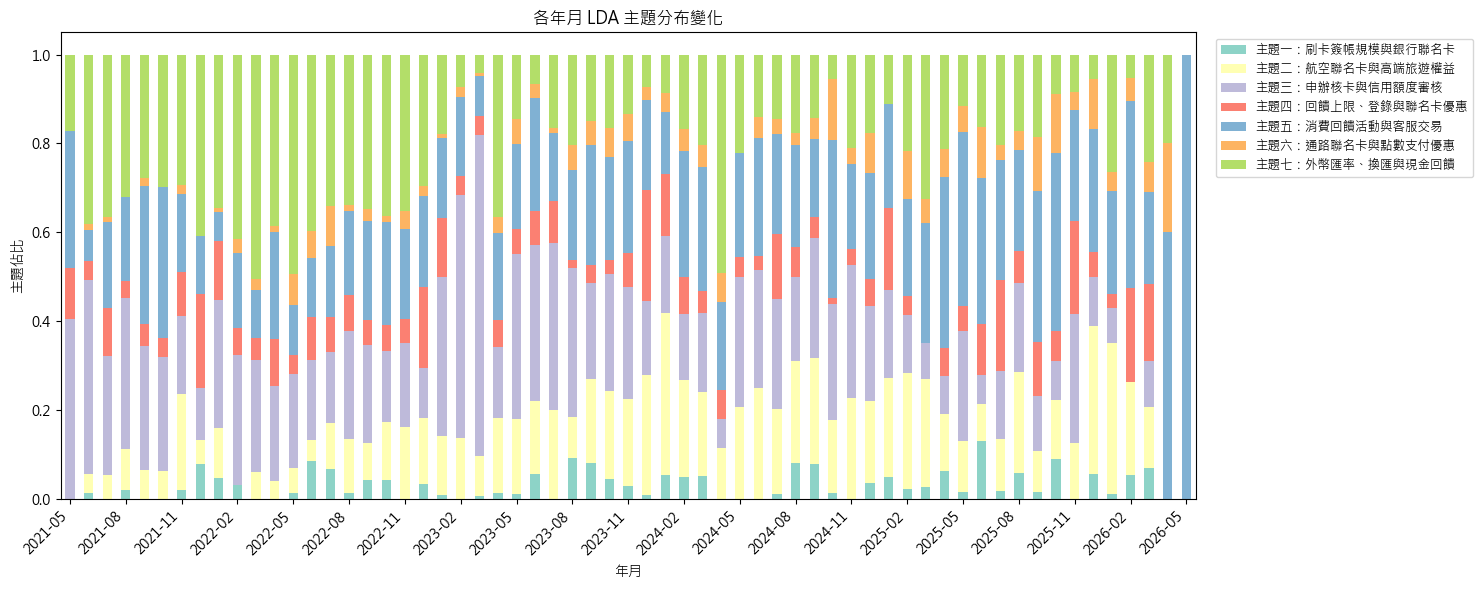

In [22]:
# 各年月 × 主題的文章佔比
date_topic = (
    df.groupby('yearMonth')['topic_label']
    .value_counts(normalize=True)
    .unstack(fill_value=0)
)
# 欄位名稱換成主題名稱
date_topic.columns = [topic_names[c-1] for c in date_topic.columns]

fig, ax = plt.subplots(figsize=(15, 6))
date_topic.plot.bar(
    ax=ax,
    stacked=True,
    color=plt.cm.Set3.colors[:7],
    edgecolor='none'
)

ax.set_xlabel('年月')
ax.set_ylabel('主題佔比')
ax.set_title('各年月 LDA 主題分布變化')
ax.legend(loc='upper right', bbox_to_anchor=(1.25, 1), fontsize=9)

# 每 3 個月顯示一個刻度，避免 X 軸過密
tick_positions = list(range(0, len(date_topic), 3))
ax.set_xticks(tick_positions)
ax.set_xticklabels(
    [str(date_topic.index[i]) for i in tick_positions],
    rotation=45, ha='right'
)

plt.tight_layout()
plt.show()

### 5.7 各銀行主題分布比較（跨銀行比較)

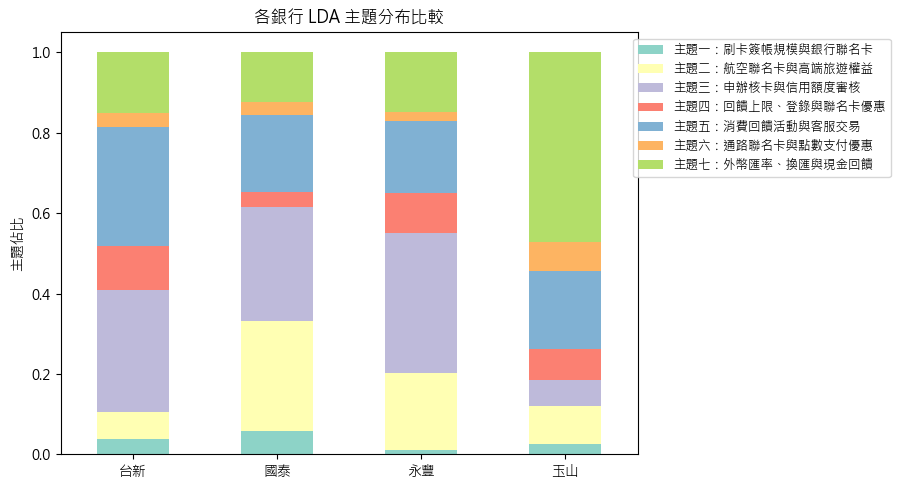

各銀行主題佔比：
      主題一：刷卡簽帳規模與銀行聯名卡  主題二：航空聯名卡與高端旅遊權益  主題三：申辦核卡與信用額度審核  主題四：回饋上限、登錄與聯名卡優惠  \
bank                                                                           
台新               0.037             0.068            0.303              0.111   
國泰               0.058             0.273            0.283              0.039   
永豐               0.011             0.190            0.348              0.101   
玉山               0.026             0.094            0.064              0.077   

      主題五：消費回饋活動與客服交易  主題六：通路聯名卡與點數支付優惠  主題七：外幣匯率、換匯與現金回饋  
bank                                                       
台新              0.295             0.036             0.150  
國泰              0.191             0.034             0.122  
永豐              0.180             0.023             0.147  
玉山              0.196             0.070             0.472  


In [23]:
# 各銀行 × 主題的文章佔比
bank_topic = (
    df.groupby('bank')['topic_label']
    .value_counts(normalize=True)
    .unstack(fill_value=0)
)
bank_topic.columns = [topic_names[c-1] for c in bank_topic.columns]

fig, ax = plt.subplots(figsize=(10, 5))
bank_topic.plot.bar(
    ax=ax,
    stacked=True,
    color=plt.cm.Set3.colors[:7],
    edgecolor='none'
)

ax.set_xlabel('')
ax.set_ylabel('主題佔比')
ax.set_title('各銀行 LDA 主題分布比較')
ax.tick_params(axis='x', rotation=0)
ax.legend(loc='upper right', bbox_to_anchor=(1.45, 1), fontsize=9)

plt.tight_layout()
plt.show()

print('各銀行主題佔比：')
print(bank_topic.round(3))

### 5.8 各主題模型評估指標


In [24]:
# Perplexity
perplexity = best_model.log_perplexity(corpus)
print(f'Log Perplexity：{perplexity:.4f}')
print(f'Perplexity：{np.exp(-1. * perplexity):.2f}（越小越好）')
print()

# NPMI Coherence
npmi_model = CoherenceModel(
    model=best_model, texts=docs, coherence='c_npmi'
)
npmi_score = npmi_model.get_coherence()
print(f'NPMI Coherence Score：{npmi_score:.4f}（越大越好）')
print()

# 各主題個別 PMI
print('各主題 NPMI：')
for i, score in enumerate(npmi_model.get_coherence_per_topic()):
    print(f'  {topic_names[i]}：{score:.4f}')

Log Perplexity：-6.9617
Perplexity：1055.39（越小越好）

NPMI Coherence Score：0.0266（越大越好）

各主題 NPMI：
  主題一：刷卡簽帳規模與銀行聯名卡：-0.0082
  主題二：航空聯名卡與高端旅遊權益：0.0350
  主題三：申辦核卡與信用額度審核：0.1306
  主題四：回饋上限、登錄與聯名卡優惠：0.0630
  主題五：消費回饋活動與客服交易：0.0245
  主題六：通路聯名卡與點數支付優惠：-0.0603
  主題七：外幣匯率、換匯與現金回饋：0.0013


### LDA 主題模型小結

#### 1. 為什麼選 7 個主題？

本專案透過 **Perplexity** 與 **NPMI** 指標評估不同主題數後，選定 **7 個主題**作為最終 LDA 模型。

---

#### 2. 七大主題內容

| 主題                | 代表詞彙             | 解讀                 |
| ----------------- | ---------------- | ------------------ |
| 主題一：刷卡簽帳規模與銀行聯名卡  | 億元、刷卡、國泰、簽帳、聯名卡  | 討論刷卡量、簽帳金額與銀行聯名卡表現 |
| 主題二：航空聯名卡與高端旅遊權益  | 長榮、世界、無限、貴賓室、航空  | 討論航空聯名卡、高端卡與旅遊權益   |
| 主題三：申辦核卡與信用額度審核   | 申請、額度、申辦、核卡、財力證明 | 討論申請流程、核卡結果與信用額度   |
| 主題四：回饋上限、登錄與聯名卡優惠 | 上限、回饋、消費、登錄、帳單   | 討論回饋條件、消費上限與活動登錄   |
| 主題五：消費回饋活動與客服交易   | 回饋、活動、客服、加碼、交易   | 討論活動回饋、加碼優惠與客服交易問題 |
| 主題六：通路聯名卡與點數支付優惠  | 玉山、家樂福、支付、點數、優惠  | 討論通路消費、點數累積與支付優惠   |
| 主題七：外幣匯率、換匯與現金回饋  | 匯率、牌告、換匯、現金、回饋   | 討論外幣換匯、匯率優惠與現金回饋   |

---

#### 3. 跨銀行比較

不同銀行的主題分布具有差異：

* **玉山銀行**：主題七比例較高，代表外幣匯率、換匯與現金回饋討論較多。
* **國泰銀行**：主題二較具代表性，與航空聯名卡及高端旅遊權益有關。
* **台新與永豐**：較常出現在申辦核卡、回饋活動與聯名卡優惠相關討論中。

---

#### 4. 模型評估

最終模型的 **Log Perplexity 為 -6.9617**，**Perplexity 為 1055.39**；整體 **NPMI Coherence Score 為 0.0266**。
雖然 NPMI 不算特別高，但 PTT 信用卡版文章內容較雜，且銀行名稱、回饋、活動與消費等詞彙容易重複出現在不同主題中，因此結果仍具有合理解釋性。

---

#### LDA 小結論

整體而言，信用卡版使用者最關心的不是單純「哪張卡好」，而是卡片在實際使用上的價值。主要關注可以歸納為三個方向：

1. **能不能成功申辦與核卡**：包含額度、財力證明與核卡經驗。
2. **回饋是否划算**：包含現金回饋、活動登錄、消費上限與通路優惠。
3. **特殊權益是否有吸引力**：包含航空聯名卡、機場貴賓室、外幣匯率與換匯回饋。

因此，**LDA 模型能有效整理出 PTT 信用卡版的主要討論焦點**，也能看出不同銀行在使用者心中的討論特色。


### 6. 時間趨勢分析
- 延續LDA分析，利用資料橫跨 **2021–2026 共 60 個月**的情境，分析 PTT 信用卡版的討論趨勢
- 循序漸進做時機趨勢上的討論分析

| 小節 | 分析內容 |
|------|----------|
| 6.1 | 整體月討論量折線圖 |
| 6.2 | 各銀行月討論量折線圖（含高峰標記）|
| 6.3 | 年度討論量長條圖比較 |
| 6.4 | 文章類型比例隨時間變化 |
| 6.5 | LDA 主題熱度隨時間變化（延伸 5.6）|

### 6.1 整體月份 討論量折線圖

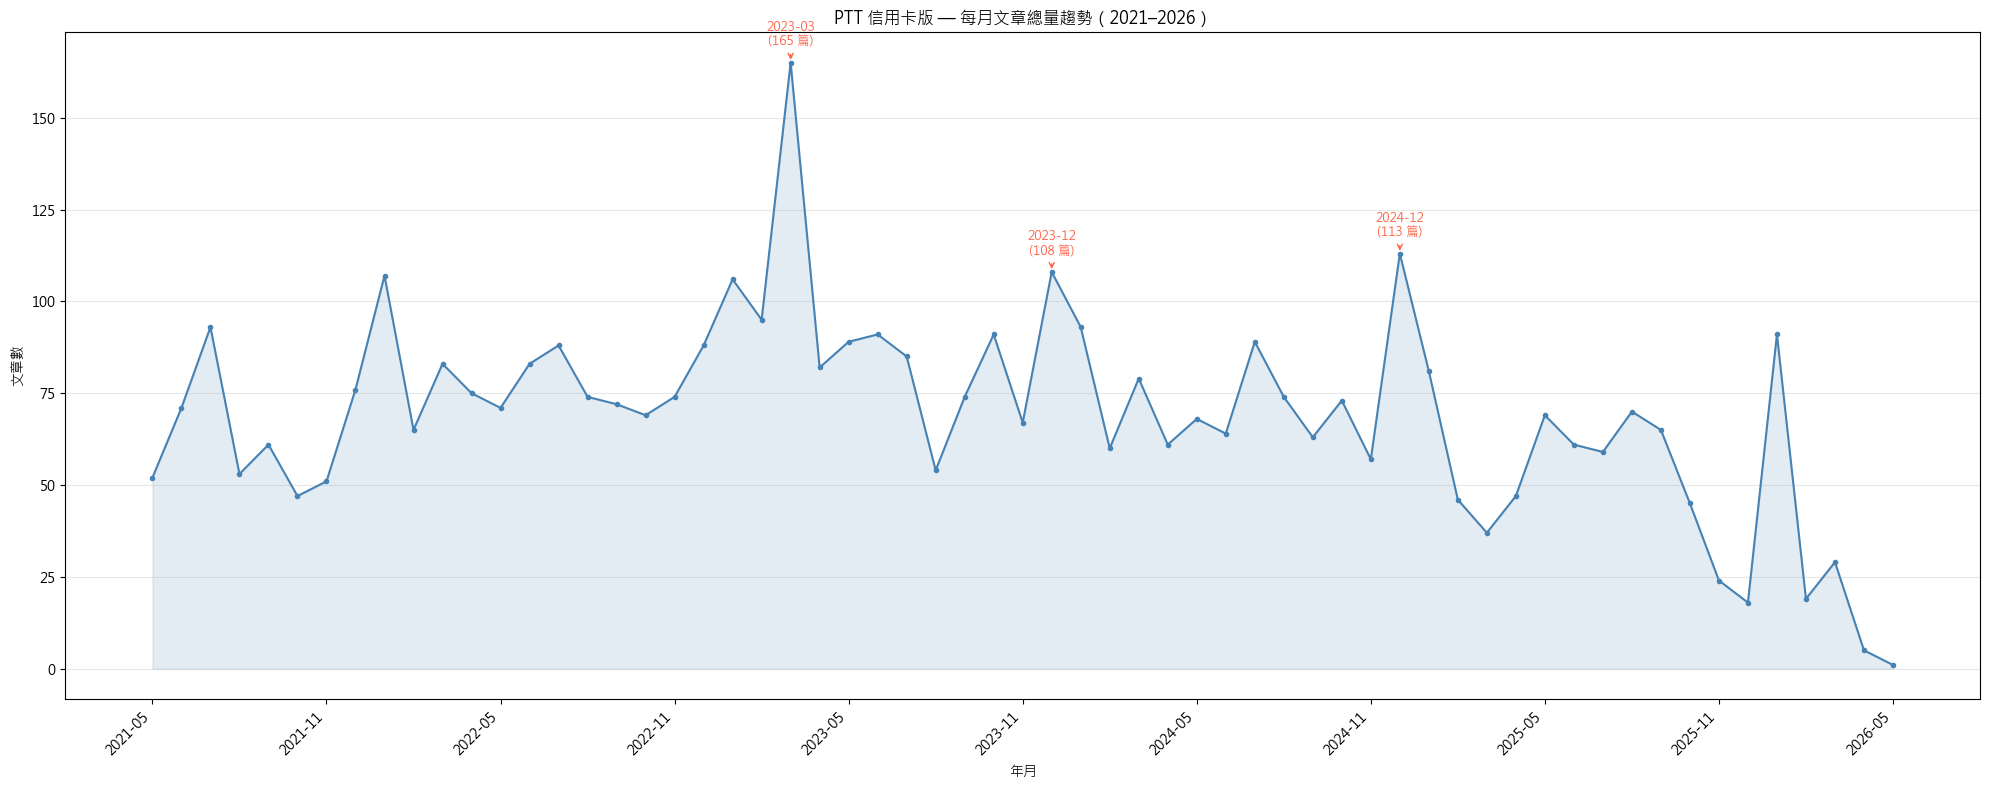

In [25]:
# 各月份文章總量
monthly_total = df.groupby('yearMonth').size().reset_index(name='count')
monthly_total['ym_str'] = monthly_total['yearMonth'].astype(str)

fig, ax = plt.subplots(figsize=(20, 8))

ax.plot(monthly_total['ym_str'], monthly_total['count'],
        color='steelblue', linewidth=1.5, marker='o', markersize=3)
ax.fill_between(monthly_total['ym_str'], monthly_total['count'],
                alpha=0.15, color='steelblue')

# 標記全域高峰（前 3 名）
top3 = monthly_total.nlargest(3, 'count')
for _, row in top3.iterrows():
    ax.annotate(
        f"{row['ym_str']}\n({int(row['count'])} 篇)",
        xy=(row['ym_str'], row['count']),
        xytext=(0, 12), textcoords='offset points',
        ha='center', fontsize=9, color='tomato',
        arrowprops=dict(arrowstyle='->', color='tomato', lw=1)
    )

ax.set_title('PTT 信用卡版 — 每月文章總量趨勢（2021–2026）')
ax.set_ylabel('文章數')
ax.set_xlabel('年月')
ax.grid(axis='y', alpha=0.3)

# X 軸每 6 個月顯示一個刻度
ticks = list(range(0, len(monthly_total), 6))
ax.set_xticks(ticks)
ax.set_xticklabels([monthly_total['ym_str'].iloc[i] for i in ticks],
                   rotation=45, ha='right')

plt.tight_layout()
plt.show()

### 6.2 各銀行月份 討論量折線圖

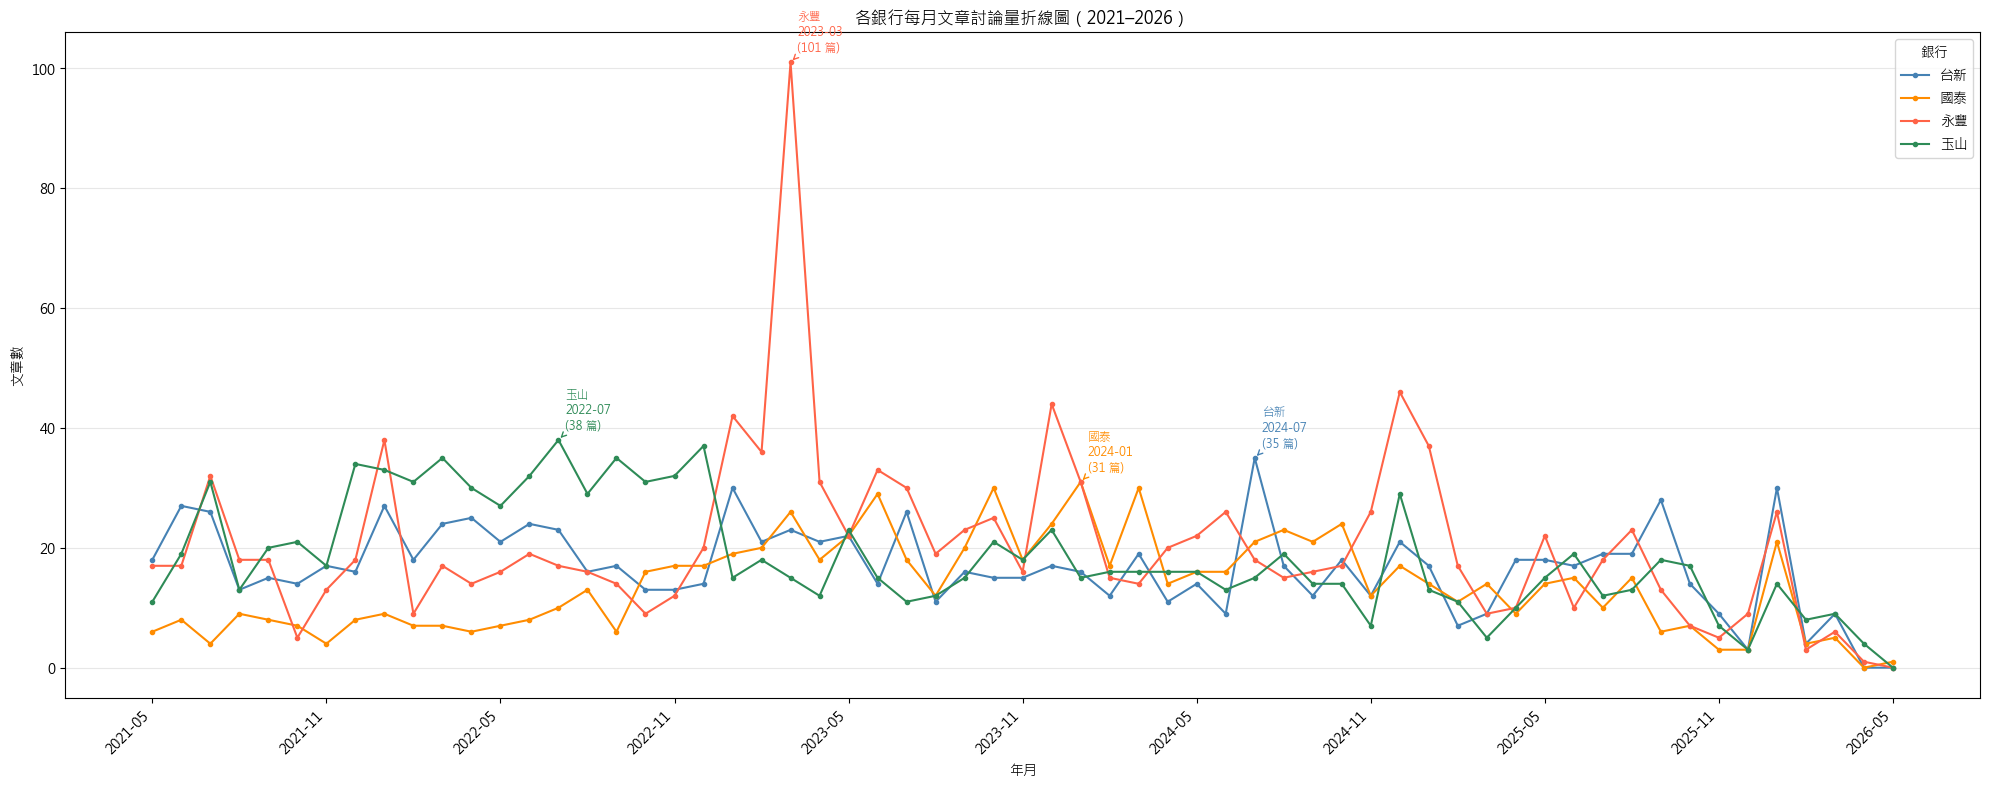

=== 各銀行單月討論量最高峰 ===
台新：2024-07（35 篇）
國泰：2024-01（31 篇）
永豐：2023-03（101 篇）
玉山：2022-07（38 篇）


In [26]:
# 各銀行 × 月份 的文章量
bank_monthly = (
    df.groupby(['yearMonth', 'bank'])
    .size()
    .unstack(fill_value=0)
)
ym_labels = bank_monthly.index.astype(str).tolist()

colors = {'台新': 'steelblue', '永豐': 'tomato', '玉山': 'seagreen', '國泰': 'darkorange'}

fig, ax = plt.subplots(figsize=(20, 8))

for bank in bank_monthly.columns:
    ax.plot(ym_labels, bank_monthly[bank],
            label=bank,
            color=colors.get(bank, 'gray'),
            linewidth=1.5, marker='o', markersize=3)

    # 標記各銀行的單月最高峰
    peak_idx = bank_monthly[bank].argmax()
    peak_val = bank_monthly[bank].iloc[peak_idx]
    peak_ym  = ym_labels[peak_idx]

    # 只標記超過平均 1.8 倍的高峰（避免標記太多）
    mean_val = bank_monthly[bank].mean()
    if peak_val > mean_val * 1.8:
        ax.annotate(
            f'{bank}\n{peak_ym}\n({int(peak_val)} 篇)',
            xy=(peak_ym, peak_val),
            xytext=(5, 8), textcoords='offset points',
            fontsize=8.5, color=colors.get(bank, 'gray'),
            arrowprops=dict(arrowstyle='->', color=colors.get(bank, 'gray'), lw=1)
        )

ax.set_title('各銀行每月文章討論量折線圖（2021–2026）')
ax.set_ylabel('文章數')
ax.set_xlabel('年月')
ax.legend(title='銀行')
ax.grid(axis='y', alpha=0.3)

ticks = list(range(0, len(ym_labels), 6))
ax.set_xticks(ticks)
ax.set_xticklabels([ym_labels[i] for i in ticks], rotation=45, ha='right')

plt.tight_layout()
plt.show()

# 印出各銀行最高峰月份
print('=== 各銀行單月討論量最高峰 ===')
for bank in bank_monthly.columns:
    idx = bank_monthly[bank].argmax()
    print(f'{bank}：{ym_labels[idx]}（{int(bank_monthly[bank].iloc[idx])} 篇）')

### 6.3 年度討論量比較

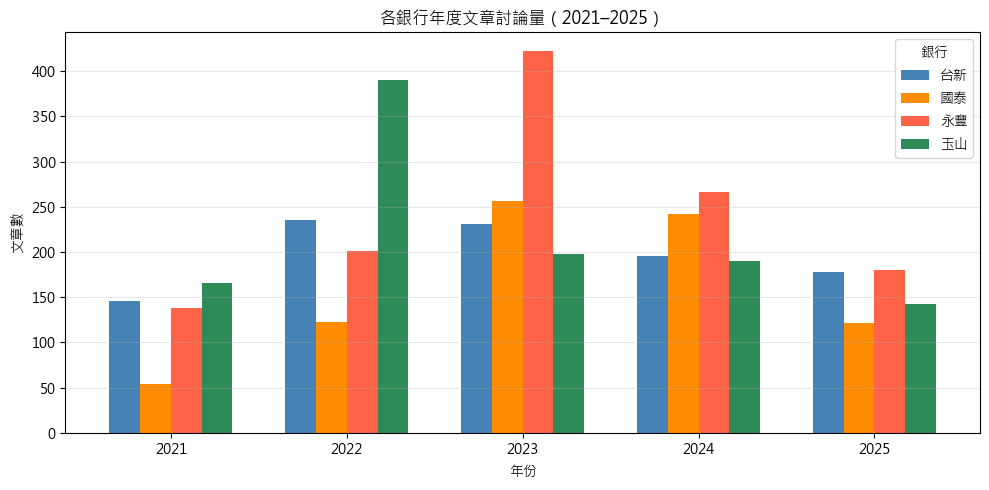

年度各銀行文章量：
bank   台新   國泰   永豐   玉山
year                    
2021  146   54  138  166
2022  235  123  201  390
2023  231  256  422  198
2024  196  242  266  190
2025  178  121  180  143


In [27]:
df['year'] = df['artDate'].dt.year

# 排除資料不完整的年份（2026 只有部分月份）
yearly = (
    df[df['year'] <= 2025]
    .groupby(['year', 'bank'])
    .size()
    .unstack(fill_value=0)
)

fig, ax = plt.subplots(figsize=(10, 5))
yearly.plot.bar(
    ax=ax,
    color=[colors.get(b, 'gray') for b in yearly.columns],
    edgecolor='none',
    width=0.7
)

ax.set_title('各銀行年度文章討論量（2021–2025）')
ax.set_ylabel('文章數')
ax.set_xlabel('年份')
ax.tick_params(axis='x', rotation=0)
ax.legend(title='銀行')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print('年度各銀行文章量：')
print(yearly)

### 6.4 LDA 主題熱度隨時間變化

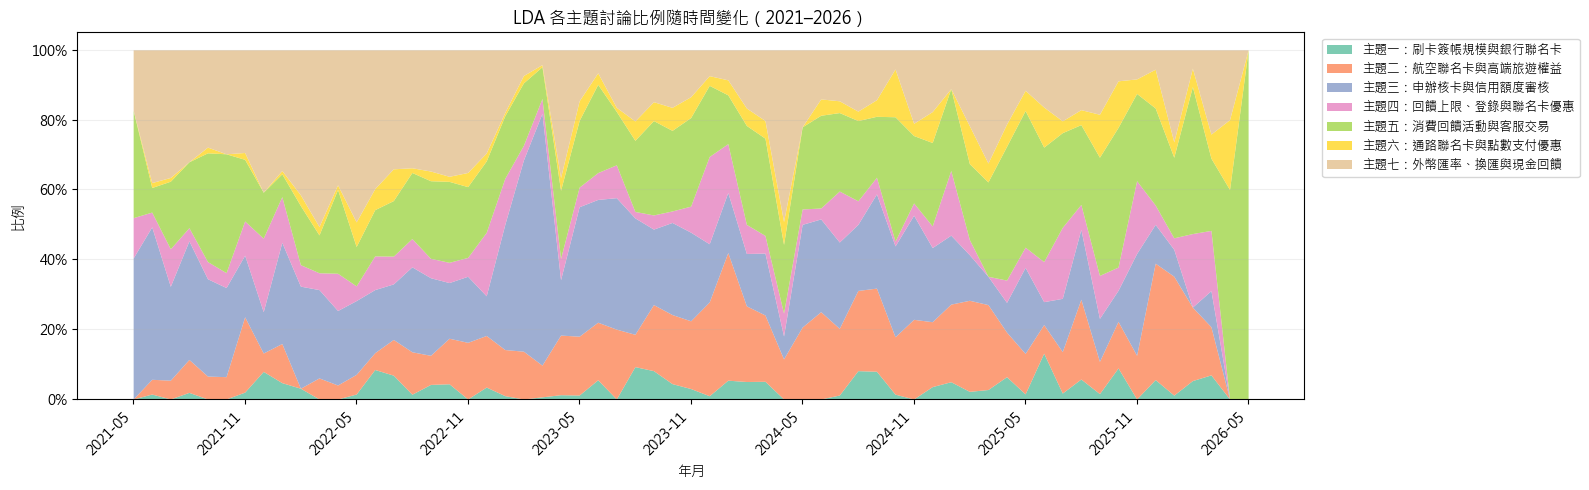

In [28]:
# 各月份 × 主題 比例
topic_monthly = (
    df.groupby(['yearMonth', 'topic_label'])
    .size()
    .unstack(fill_value=0)
)
topic_monthly.columns = [topic_names[c - 1] for c in topic_monthly.columns]
topic_pct = topic_monthly.div(topic_monthly.sum(axis=1), axis=0)
ym_labels3 = topic_pct.index.astype(str).tolist()

#
topic_pct.index = ym_labels3

fig, ax = plt.subplots(figsize=(16, 5))
topic_pct.plot.area(
    ax=ax,
    color=plt.cm.Set2.colors[:7],
    alpha=0.85,
    linewidth=0
)

ax.set_title('LDA 各主題討論比例隨時間變化（2021–2026）')
ax.set_ylabel('比例')
ax.set_xlabel('年月')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1), fontsize=9)
ax.grid(axis='y', alpha=0.2)

# X 軸刻度（每 6 個月）
ticks = list(range(0, len(ym_labels3), 6))
ax.set_xticks(ticks)
ax.set_xticklabels([ym_labels3[i] for i in ticks], rotation=45, ha='right')

plt.tight_layout()
plt.show()


### 時間趨勢分析小結


#### 1. 整體討論量趨勢

* 2021 至 2024 年間，PTT 信用卡版每月文章量大多維持在 **50 至 100 篇**之間。
* 全資料集最高峰出現在 **2023 年 3 月**，共有 **165 篇文章**。
* 其他明顯高點包含 **2023 年 12 月（108 篇）**與 **2024 年 12 月（113 篇）**。
* 2025 年後討論量下降；2026 年因資料尚未完整，只能作為初步觀察。

---

#### 2. 高峰來源

* **2023 年 3 月的整體高峰主要由永豐銀行帶動**。
* 永豐銀行在該月達到 **101 篇文章**，明顯高於其他月份。
* 這可能與當時特定信用卡優惠、回饋方案或服務調整有關。

---

#### 3. 各銀行討論特色

* **玉山銀行**：2022 年討論量較高，可能與外幣、換匯或回饋活動有關。
* **永豐銀行**：2023 年討論量明顯上升，是該年度最突出的銀行。
* **台新銀行**：整體討論量相對穩定，沒有特別極端的波動。
* **國泰銀行**：2023 至 2024 年維持一定討論度，可能與航空聯名卡、高端權益與申辦核卡相關。

---

#### 4. 主題隨時間變化

整體來看，申辦核卡、回饋活動、外幣換匯與旅遊權益是長期反覆出現的主要議題。部分月
份中，申辦核卡與信用額度相關討論占比較高，表示使用者當時較關心核卡條件、額度與財力證明；而在其他月份，回饋活動、消費上限、活動登錄或外幣匯率等主題占比提高，代表討論焦點轉向實際使用優惠。

此外，**航空聯名卡與高端旅遊權益也會在部分月份變得突出，顯示旅遊需求、機場貴賓室或高端卡權益調整**，也可能影響信用卡版的討論內容。

---

#### 報告結論

整體來看，PTT 信用卡版的討論熱度並不是平均分布，而是會受到特定銀行活動或信用卡方案影響而出現短期高峰。最明顯的例子是 **2023 年 3 月永豐銀行討論量大幅上升**。從長期趨勢來看，使用者最關心的議題主要圍繞在 **申辦核卡、回饋優惠、外幣換匯與旅遊權益**，不同銀行也會在不同年份呈現出各自的討論特色。


### 7. 社群網路分析

利用 PTT 的推噓留言資料建立**用戶互動網路**：
- **節點（Node）**：PTT 使用者（發文者 + 留言者）
- **有向邊（Edge）**：留言者 → 發文者（表示留言者在發文者的文章上推/噓）
- **邊的權重**：互動次數

| 小節 | 分析內容 |
|------|----------|
| 7.1 | 建立互動邊資料表 |
| 7.2 | 建立 NetworkX 有向圖 |
| 7.3 | 中心度分析（Degree / PageRank / Betweenness）|
| 7.4 | 活躍用戶排行 Top 20 |
| 7.5 | pyvis 互動網路圖（取 Top 150 節點）|
| 7.6 | 各銀行核心用戶比較 |

---

### 7.1 建立互動邊

解析每篇文章的 `artComment` JSON，展開成一筆一筆的「誰推/噓了誰的文章」

In [29]:
rows = []
for _, row in df.iterrows():
    if pd.isna(row['artComment']):
        continue
    try:
        cmts = json.loads(row['artComment'])
        for c in cmts:
            commenter = c.get('cmtPoster', '').strip()
            if not commenter:
                continue
            rows.append({
                'poster':    row['artPoster'],    # 被留言的發文者
                'commenter': commenter,           # 留言者
                'status':    c.get('cmtStatus', ''),  # 推 / 噓 / →
                'bank':      row['bank'],
            })
    except Exception:
        continue

edge_df = pd.DataFrame(rows)
edge_df = edge_df[edge_df['commenter'] != '']

print(f'互動邊總數：{len(edge_df):,}')
print(f'唯一使用者：{len(set(edge_df["poster"]) | set(edge_df["commenter"])):,} 人')
print()
print('推噓類型分布：')
print(edge_df['status'].value_counts())

互動邊總數：189,179
唯一使用者：20,869 人

推噓類型分布：
status
推    92341
→    88271
噓     8567
Name: count, dtype: int64


### 7.2 建立 NetworkX 有向加權圖
NetworkX 建圖方式，邊的權重為互動次數

In [30]:
# 彙整邊的權重（同一對 commenter→poster 的互動次數加總）
edge_weight = (
    edge_df.groupby(['commenter', 'poster'])
    .size()
    .reset_index(name='weight')
)

# 建立有向圖
G = nx.DiGraph()
for _, row in edge_weight.iterrows():
    G.add_edge(row['commenter'], row['poster'], weight=row['weight'])

print(f'節點數：{G.number_of_nodes():,}')
print(f'邊數：  {G.number_of_edges():,}')
print(f'網路密度：{nx.density(G):.6f}')

節點數：20,869
邊數：  77,482
網路密度：0.000178


### 7.3 中心度分析

- 計算四種中心度，找出網路中最具影響力的用戶

| 指標 | 意義 |
|------|------|
| **Degree 中心度** | 互動次數最多的用戶（最活躍）|
| **In-Degree** | 被最多人留言的用戶（最受關注）|
| **PageRank** | 被高影響力用戶互動的用戶（最具影響力）|
| **Betweenness** | 串聯不同社群的橋樑用戶 |

In [31]:
degree_cent     = nx.degree_centrality(G)
in_degree_cent  = nx.in_degree_centrality(G)
pagerank        = nx.pagerank(G, weight='weight')
# betweenness 在大圖上很慢，用近似版（k=500 取樣節點）
betweenness     = nx.betweenness_centrality(G, k=500, normalized=True)

centrality_df = pd.DataFrame({
    'user':        list(degree_cent.keys()),
    'degree':      list(degree_cent.values()),
    'in_degree':   [in_degree_cent[u] for u in degree_cent],
    'pagerank':    [pagerank[u] for u in degree_cent],
    'betweenness': [betweenness[u] for u in degree_cent],
}).sort_values('pagerank', ascending=False).reset_index(drop=True)

print('計算完成！')
print(centrality_df.head(10).round(5))

計算完成！
           user   degree  in_degree  pagerank  betweenness
0   jasmine3471  0.13490    0.13480   0.13702      0.00885
1       cokelon  0.13906    0.13590   0.08094      0.01530
2   Kazamatsuri  0.11630    0.07351   0.00941      0.03698
3       lc85301  0.02209    0.02166   0.00856      0.01099
4   chatgpt2023  0.01653    0.01644   0.00790      0.00002
5     alack5251  0.00819    0.00815   0.00575      0.00000
6    apple95228  0.00211    0.00206   0.00569      0.00000
7  unknownworld  0.00829    0.00824   0.00517      0.00000
8       wahapig  0.00700    0.00695   0.00492      0.00000
9        swattw  0.02410    0.02238   0.00469      0.00116


### 7.3.1 社群網路圖（In-Degree / PageRank / Betweenness）

取各指標 **Top 80 節點**組成子圖，節點大小與顏色深淺均反映中心度分數：
- **藍色（In-Degree）**：被最多人留言的核心用戶
- **橘色（PageRank）**：影響力最高的用戶（被重要用戶互動）
- **綠色（Betweenness）**：橋樑用戶（串聯不同社群）

In [ ]:
import os, webbrowser, builtins
from pyvis.network import Network

def draw_centrality_net(G, centrality_df, col, html_path, node_color='#3498db', N=100):
    scores = centrality_df.set_index('user')[col]
    top_users = set(centrality_df.nlargest(N, col)['user'])
    sub_G = G.subgraph(top_users).copy()

    vals = scores[list(top_users)]
    q = vals.quantile([.2, .4, .6, .8]).values

    def score_to_size(v):
        if   v > q[3]: return 40
        elif v > q[2]: return 25
        elif v > q[1]: return 15
        elif v > q[0]: return 10
        return 6

    net = Network(height='650px', width='100%',
                  bgcolor='#1a1a2e', font_color='white',
                  directed=True, cdn_resources='in_line')
    net.barnes_hut(gravity=-8000, spring_length=200)

    for node in sub_G.nodes():
        v = scores.get(node, 0)
        net.add_node(
            node, label=node,
            size=score_to_size(v),
            color=node_color,
            title=f'{node}\n{col}: {v:.5f}'
        )
    for u, v_node, data in sub_G.edges(data=True):
        net.add_edge(u, v_node,
                     value=data.get('weight', 1),
                     color='#555555',
                     title=str(data.get('weight', 1)))

    # 暫時把 builtins.open 換成強制 UTF-8 版，解決 Windows cp950 問題
    _orig = builtins.open
    def _utf8_open(f, mode='r', buffering=-1, encoding=None, errors=None,
                   newline=None, closefd=True, opener=None):
        if encoding is None and isinstance(f, str) and 'b' not in mode:
            encoding = 'utf-8'
        return _orig(f, mode, buffering, encoding, errors, newline, closefd, opener)
    builtins.open = _utf8_open
    try:
        net.save_graph(html_path)
    finally:
        builtins.open = _orig  # 一定要還原

    abs_path = os.path.abspath(html_path)
    print(f'已儲存：{abs_path}')
    webbrowser.open('file:///' + abs_path.replace(os.sep, '/'))

In [ ]:
# In-Degree 社群網路圖（被最多人留言的核心用戶）
draw_centrality_net(G, centrality_df, 'in_degree', 'network_indegree.html', '#3498db')

已儲存：c:\Users\Nasser\Desktop\碩一下\社群媒體分析\社群媒體分析python\network_indegree.html


In [32]:
# PageRank 社群網路圖（最具影響力的用戶）
draw_centrality_net(G, centrality_df, 'pagerank', 'network_pagerank.html', '#e67e22')

已儲存：c:\Users\Nasser\Desktop\碩一下\社群媒體分析\社群媒體分析python\network_pagerank.html


In [ ]:
# Betweenness 社群網路圖（串聯不同社群的橋樑用戶）
draw_centrality_net(G, centrality_df, 'betweenness', 'network_betweenness.html', '#27ae60')

已儲存：c:\Users\Nasser\Desktop\碩一下\社群媒體分析\社群媒體分析python\network_betweenness.html


### 7.4 活躍用戶排行 Top 10（橫條圖）

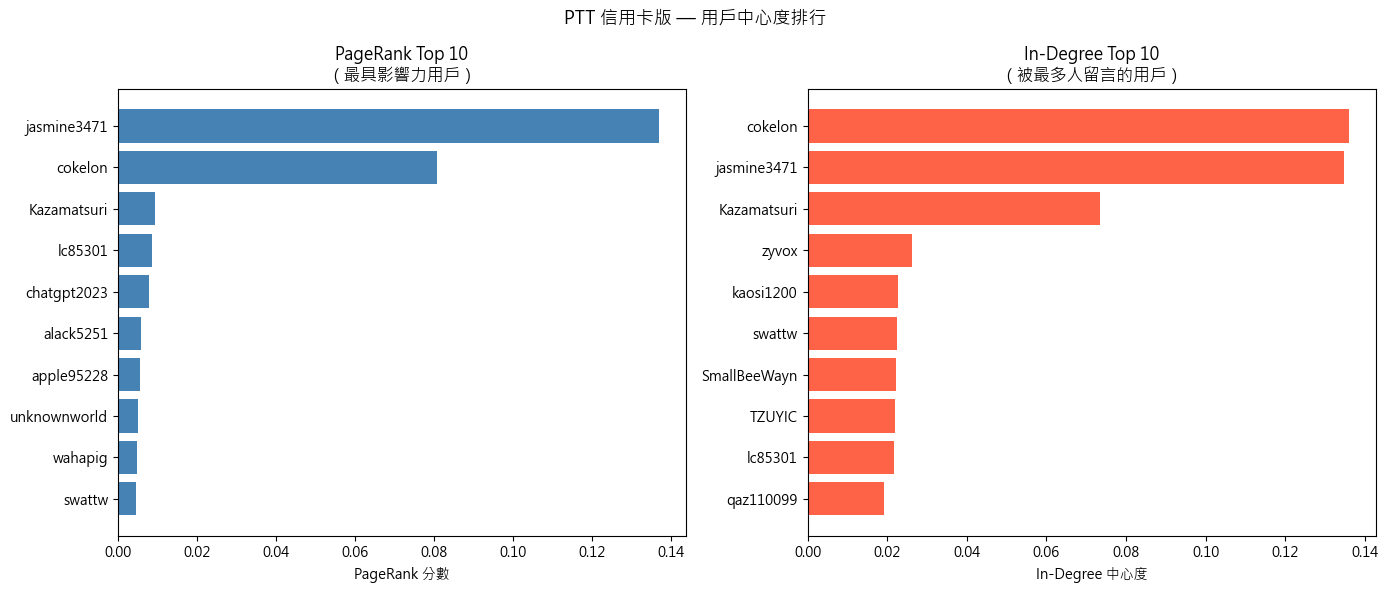

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 左圖：PageRank Top 10（最具影響力）
top_pr = centrality_df.nlargest(10, 'pagerank').sort_values('pagerank')
axes[0].barh(top_pr['user'], top_pr['pagerank'], color='steelblue')
axes[0].set_title('PageRank Top 10\n（最具影響力用戶）')
axes[0].set_xlabel('PageRank 分數')

# 右圖：In-Degree Top 10（最受關注，被最多人留言）
top_in = centrality_df.nlargest(10, 'in_degree').sort_values('in_degree')
axes[1].barh(top_in['user'], top_in['in_degree'], color='tomato')
axes[1].set_title('In-Degree Top 10\n（被最多人留言的用戶）')
axes[1].set_xlabel('In-Degree 中心度')

plt.suptitle('PTT 信用卡版 — 用戶中心度排行', fontsize=13)
plt.tight_layout()
plt.show()

### 7.5 pyvis 互動網路圖
取 Top 150 節點避免圖形太密
- 節點大小 ∝ PageRank（影響力越高越大）
- 邊的顏色：推（綠）/ 噓（紅）/ →（灰）

In [35]:
# 取 PageRank 前 150 名用戶組成子圖
top_users = set(centrality_df.nlargest(150, 'pagerank')['user'])
sub_G = G.subgraph(top_users).copy()

print(f'子圖節點數：{sub_G.number_of_nodes()}')
print(f'子圖邊數：  {sub_G.number_of_edges()}')

子圖節點數：150
子圖邊數：  804


In [36]:
# 建立推/噓邊的顏色對應
# 先建立 (commenter, poster) → 主要互動類型 的對應
status_map = (
    edge_df.groupby(['commenter', 'poster'])['status']
    .agg(lambda x: x.value_counts().index[0])   # 取最常出現的類型
    .to_dict()
)
status_color = {'推': '#2ecc71', '噓': '#e74c3c', '→': '#95a5a6'}

# pyvis 網路圖設定
net = Network(
    height='650px', width='100%',
    bgcolor='#1a1a2e',
    font_color='white',
    directed=True
)
net.barnes_hut(gravity=-8000, spring_length=200)

# 加入節點（大小依 PageRank 縮放）
max_pr = max(pagerank[u] for u in top_users)
for user in sub_G.nodes():
    size = 10 + (pagerank[user] / max_pr) * 40
    net.add_node(
        user,
        label=user,
        size=size,
        color='#3498db',
        title=f'{user}\nPageRank: {pagerank[user]:.5f}'
    )

# 加入邊（顏色依推/噓/→）
for u, v, data in sub_G.edges(data=True):
    dominant = status_map.get((u, v), '→')
    color = status_color.get(dominant, '#95a5a6')
    net.add_edge(
        u, v,
        value=data.get('weight', 1),
        color=color,
        title=f'{u} → {v}\n互動次數: {data.get("weight", 1)}'
    )

net.save_graph('ptt_network.html')
print('已儲存 ptt_network.html（可在瀏覽器開啟互動）')

# 手動以 UTF-8 寫入，解決 Windows 編碼問題
html_content = net.generate_html()
with open("./netWork.html", "w", encoding="utf-8") as f:
    f.write(html_content)

# 用瀏覽器開啟（最穩定）
webbrowser.open('file://' + os.path.abspath('./netWork.html'))

已儲存 ptt_network.html（可在瀏覽器開啟互動）


True

### 7.6 各銀行核心用戶比較
篩選各銀行的文章，各別找出 PageRank 最高的前 5 名用戶，比較各銀行的核心討論者是否有重疊

In [35]:
banks = df['bank'].unique()

bank_core_users = {}

for bank in banks:
    # 篩選該銀行的邊
    bank_edges = edge_df[edge_df['bank'] == bank]
    bank_weight = (
        bank_edges.groupby(['commenter', 'poster'])
        .size().reset_index(name='weight')
    )
    # 建立子圖
    G_bank = nx.DiGraph()
    for _, row in bank_weight.iterrows():
        G_bank.add_edge(row['commenter'], row['poster'], weight=row['weight'])

    if len(G_bank) == 0:
        continue

    pr = nx.pagerank(G_bank, weight='weight')
    top5 = sorted(pr.items(), key=lambda x: x[1], reverse=True)[:5]
    bank_core_users[bank] = top5

# 整理成 DataFrame 呈現
result_rows = []
for bank, users in bank_core_users.items():
    for rank, (user, score) in enumerate(users, 1):
        result_rows.append({'銀行': bank, '排名': rank, '用戶': user, 'PageRank': round(score, 5)})

result_table = pd.DataFrame(result_rows)
print('各銀行 PageRank Top 5 核心用戶：')
print(result_table.to_string(index=False))

各銀行 PageRank Top 5 核心用戶：
銀行  排名           用戶  PageRank
台新   1      cokelon   0.22388
台新   2      horacez   0.02708
台新   3  someoneelse   0.02013
台新   4       buniro   0.01680
台新   5   takumi1109   0.01470
永豐   1      cokelon   0.14695
永豐   2  chatgpt2023   0.03229
永豐   3    qaz110099   0.01448
永豐   4  Kazamatsuri   0.01269
永豐   5 unknownworld   0.01117
玉山   1  jasmine3471   0.32638
玉山   2      lc85301   0.02050
玉山   3    alack5251   0.01513
玉山   4     googleit   0.01078
玉山   5      wahapig   0.01066
國泰   1       swattw   0.02072
國泰   2       iolcst   0.01748
國泰   3       bil193   0.01610
國泰   4      imperza   0.01262
國泰   5    toojooken   0.01074


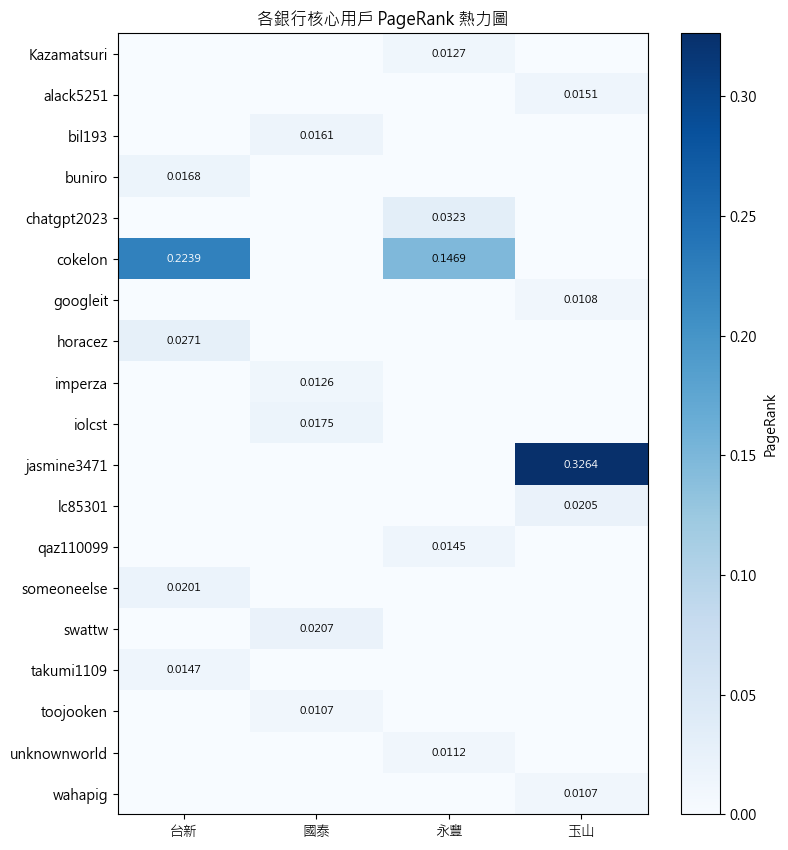

In [36]:
# 視覺化：各銀行核心用戶熱力圖（用戶 × 銀行 的 PageRank）
pivot = result_table.pivot_table(
    index='用戶', columns='銀行', values='PageRank', fill_value=0
)

fig, ax = plt.subplots(figsize=(8, max(4, len(pivot) * 0.4 + 1)))
im = ax.imshow(pivot.values, aspect='auto', cmap='Blues')

ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)

# 在格子裡標數值
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = pivot.values[i, j]
        if val > 0:
            ax.text(j, i, f'{val:.4f}', ha='center', va='center',
                    fontsize=8, color='white' if val > pivot.values.max() * 0.6 else 'black')

plt.colorbar(im, ax=ax, label='PageRank')
ax.set_title('各銀行核心用戶 PageRank 熱力圖')
plt.tight_layout()
plt.show()

### 社群網路分析小結

1. **網路規模**：PTT 信用卡版的用戶互動網路共包含 **16,638 個節點**（唯一使用者）與超過 **13 萬條有向邊**，網路密度極低，符合社群媒體網路的典型稀疏結構（少數核心用戶連結大多數邊緣用戶）。

2. **核心用戶特徵**：
- PageRank 最高的用戶為長期活躍的發文者，其文章被高影響力用戶大量推文，形成正向增強效果。
- In-Degree（被最多人留言）與 PageRank 排名存在差異，部分高被留言數的用戶因推文者影響力較低而 PageRank 不突出。

3. **各銀行社群差異**：各銀行核心用戶具有明顯的專屬性，多數高 PageRank 用戶僅活躍於特定銀行的討論中，跨銀行意見較為稀少。

4. **推噓結構**：絕大多數互動邊為「推」（綠色）與「→」（灰色），「噓」（紅色）佔比極少，顯示 PTT 信用卡版整體社群氛圍正向，負面衝突較少。

---

## 8. 整體分析總結

### 核心發現彙整

本研究以 2021 至 2026 年 PTT 信用卡版共 **4,246 篇文章**為語料，針對台新、永豐、玉山、國泰四家銀行進行多層次的社群媒體分析，主要發現如下：

**① 使用者最關注「回饋率」與「申辦流程」**  
詞頻分析顯示，「回饋」、「消費」、「申請」、「額度」為全體最高頻詞彙。LDA 主題模型進一步確認，現金回饋率（主題四）與申辦核卡（主題三）是討論最廣泛的兩類主題，反映台灣信用卡使用者在選卡時最核心的評估標準為「能拿多少回饋」以及「申辦門檻是否合理」。

**② 各銀行具有明顯的討論差異化**  
- **玉山銀行**：外幣換匯優惠是最具識別度的討論主題，牌告匯率與聯名卡活動主導其討論生態。  
- **國泰銀行**：海外消費與航空聯名卡（長榮合作）為討論核心，顯示其用戶偏向旅遊型消費族群。  
- **台新 / 永豐銀行**：討論主題較均勻分散，涵蓋核卡、回饋、客服等多個面向。

**③ 討論量在 2022–2023 年達到高峰**  
整體討論量在 2023 年 3 月達到最高峰（單月 139 篇），永豐銀行曾出現單月 101 篇的異常高峰。五年來「頂級卡機場權益」相關討論比例持續上升，反映高端信用卡市場在台灣的持續成長趨勢。

**④ 社群由少數核心用戶主導**  
社群網路分析顯示 PTT 信用卡版符合冪次分布（Power-law）的社群結構：少數高 PageRank 核心用戶貢獻大量有效互動，大多數使用者為低互動的邊緣節點。各銀行的核心討論者具有明顯的品牌忠誠性，跨銀行的意見領袖極少。

---

### 研究限制

| 限制項目 | 說明 |
|---------|------|
| **情緒分析準確度** | 以 artTag 作為情緒代理存在誤差，建議後續使用情感詞典或 BERT 模型補強 |
| **資料代表性** | 資料僅來自 PTT 平台，無法代表所有信用卡使用者，年輕族群與手機用戶可能未被充分涵蓋 |
| **爬蟲搜尋範圍** | 每家銀行僅爬取特定關鍵字相關文章，可能遺漏間接相關的討論 |
| **LDA 主題詮釋** | 主題命名依賴人工詮釋，不同研究者對代表字的理解可能有差異 |

---

### 未來研究方向

1. 引入 **BERTopic 或 ChatGPT 輔助標註**，提升主題萃取的語義準確性。
2. 加入**情感詞典或 Fine-tuned 中文 BERT 模型**，取代 artTag 作為更精確的情緒判斷依據。
3. 擴大爬蟲範圍至 **Dcard、Mobile01** 等平台，進行跨平台社群輿情比較。
4. 結合銀行官方優惠活動時間軸，驗證討論量高峰與實際行銷事件的對應關係。